In [1]:
# =========================
# Standard library imports
# =========================
import sys
import os
import io
import gzip
from pathlib import Path
import math
import json
import pickle
import logging
import random
import subprocess
import warnings
import collections
import itertools
import re
from IPython.display import display

warnings.filterwarnings("ignore")


# =========================
# Numeric / stats
# =========================
import numpy as np
import pandas as pd
from scipy import sparse
from scipy import stats
from scipy.stats import rankdata
from scipy import __version__ as scipy_version


# =========================
# Plotting / visualization
# =========================
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FormatStrFormatter, MaxNLocator
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import seaborn as sns


# =========================
# scikit-learn
# =========================
from sklearn import model_selection, metrics
from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    KFold,
    GroupKFold,
    cross_val_score,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import LocalOutlierFactor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn import __version__ as sklearn_version


# =========================
# Optimization / AutoML
# =========================
import optuna


# =========================
# LightGBM
# =========================
try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
    _HAS_LGBM = True
except Exception as e:
    _HAS_LGBM = False
    raise RuntimeError(
        "LightGBM not installed. Please install it with `pip install lightgbm`."
    ) from e


# =========================
# RNA structure (ViennaRNA)
# =========================
import RNA


# =========================
# UpSet plots
# =========================
try:
    from upsetplot import UpSet, from_memberships
except Exception:
    _ = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "upsetplot"],
        check=False,
    )
    from upsetplot import UpSet, from_memberships


# =========================
# Model explanation
# =========================
import shap


# =========================
# User-provided utilities
# =========================
import sylib  


# =========================
# Version info
# =========================
print(f"python    = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas    = {pd.__version__}")
print(f"numpy     = {np.__version__}")
print(f"scipy     = {scipy_version}")
print(f"optuna    = {optuna.__version__}")
print(f"sklearn   = {sklearn_version}")
print(f"ViennaRNA = {RNA.__version__}")
print(f"lightgbm  = {lgb.__version__}")
print(f"sylib     = {sylib.__version__}")


# =========================
# Progress bar & logging
# =========================
# progress bar from sylib
progress_bar = sylib.utils.ProgressBar()

# reset handlers then configure logging
logging.root.handlers = []
stream_handler = logging.StreamHandler(sys.stderr)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)
logger = logging.getLogger(__name__)

# make matplotlib quieter
logging.getLogger("matplotlib").setLevel(logging.WARNING)

python    = 3.11.15
pandas    = 2.3.3
numpy     = 2.4.6
scipy     = 1.17.1
optuna    = 4.9.0
sklearn   = 1.9.0
ViennaRNA = 2.7.2
lightgbm  = 4.6.0
sylib     = 0.3.0.dev0+ae18bb2


In [2]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}


SPECIES_INFO = {
    "AT21": {
        "label": "AT",
        "short": "AT21",
        "color": "#664D0AFF",
        "marker": "o",
    },
    "NB21": {
        "label": "NB",
        "short": "NB21",
        "color": "#7e3131",
        "marker": "^",
    },
    "OS21": {
        "label": "OS",
        "short": "OS21",
        "color": "#13563f",
        "marker": "s",
    },
}

def set_plot_style(
    *,
    base_fontsize=10,
    title_fontsize=12,
    label_fontsize=10,
    tick_fontsize=9,
    legend_fontsize=10,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    fig_w=6.0,
    fig_h=6.0,
):
    sns.set_style("ticks")

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        "legend.frameon": False,

        "savefig.bbox": "tight",
        "savefig.transparent": False,
        "figure.autolayout": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(w=None, h=None, dpi=None):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


def _compact_formatter():
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.1f}k"
        else:
            s = f"{x:.2g}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    compact_ticks=(),
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()

    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)

    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)

    return ax


# ============================================
# Joint scatter with KDE marginals
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.spearmanr(x, y)

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    grid = np.linspace(lo, hi, num)

    if len(values) < 2:
        return grid, np.zeros_like(grid)

    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens

    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    annotate_spearman=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)

    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(
        figsize=(FW, FH),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))

    pad = 0.05 * (hi - lo if hi > lo else 1.0)

    lo -= pad
    hi += pad

    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    if show_identity:
        ax_joint.plot(
            [lo, hi],
            [lo, hi],
            ls="--",
            lw=1.2,
            color="0.65",
            zorder=1,
        )

    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)

        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(
        ax_joint,
        xlabel=xlabel,
        ylabel=ylabel,
        compact_ticks=(),
    )

    if title:
        ax_joint.set_title(title)

    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp, _ = safe_pearsonr(x, y)
        rs, _ = safe_spearmanr(x, y)

        txt = rf"$r_p = {rp:.2f}$"

        if annotate_spearman:
            txt += "\n" + rf"$r_s = {rs:.2f}$"

        txt += f"\n$n = {n}$"

        ax_joint.text(
            0.04,
            0.96,
            txt,
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)

    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")

    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()

    return fig, (ax_joint, ax_top, ax_right)


set_plot_style()

# ============================================
# Plot helper functions
# ============================================

def species_palette():
    return [
        SPECIES_INFO["AT21"]["color"],
        SPECIES_INFO["NB21"]["color"],
        SPECIES_INFO["OS21"]["color"],
    ]


def outside_legend(
    ax,
    *,
    title="Species",
    n_items=3,
    x=1.02,
    y=1.00,
):
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:n_items],
        labels[:n_items],
        title=title,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(x, y),
        borderaxespad=0,
    )

    return ax

In [3]:
# ============================================
# Prepare candidate-feature analysis data
# ============================================

RESULT_DIR = Path("/mnt/d/Ibnu/Programming/data/regression/results/lgbm")
SPECIES = ["AT21", "NB21", "OS21"]

candidate_file = RESULT_DIR / "lgbm.species_specific_candidate_table.importance_p90.sss_p90.tsv.gz"
candidate_all_df = pd.read_csv(candidate_file, sep="\t")
candidate_selected_df = candidate_all_df.loc[candidate_all_df["Selected"]].copy().reset_index(drop=True)

candidate_features = sorted(candidate_selected_df["Feature"].unique())

feature_metadata_df = (
    candidate_selected_df[["Feature", "Region", "Feature_type"]]
    .drop_duplicates()
    .sort_values("Feature")
    .reset_index(drop=True)
)

assert feature_metadata_df["Feature"].is_unique
assert set(feature_metadata_df["Feature"]) == set(candidate_features)

feature_meta_lookup = feature_metadata_df.set_index("Feature")

# --------------------------------------------
# Raw + exact model-space datasets
# --------------------------------------------

lgbm_data = {}
raw_rows, model_rows = [], []

for species_key in SPECIES:
    species = SPECIES_INFO[species_key]["label"]
    bundle_file = RESULT_DIR / f"{species_key}.lgbm.data_bundle.pkl.gz"

    with gzip.open(bundle_file, "rb") as f:
        bundle = pickle.load(f)

    assert bundle["species"] == species_key

    missing = set(candidate_features) - set(bundle["feature_names"])
    assert not missing, f"{species_key}: missing features {sorted(missing)}"

    metadata = pd.concat([bundle["train_metadata"], bundle["test_metadata"]], axis=0).copy()
    x_raw = pd.concat([bundle["x_train_raw"], bundle["x_test_raw"]], axis=0)[candidate_features].copy()
    x_model = pd.concat([bundle["x_train_model"], bundle["x_test_model"]], axis=0)[candidate_features].copy()

    assert metadata.index.equals(x_raw.index)
    assert metadata.index.equals(x_model.index)
    assert list(x_raw.columns) == candidate_features
    assert list(x_model.columns) == candidate_features

    raw_df = pd.concat([metadata, x_raw], axis=1)
    model_df = pd.concat([metadata, x_model], axis=1)

    for data_df in (raw_df, model_df):
        data_df.insert(0, "Species", species)
        data_df.insert(1, "Species_key", species_key)

    raw_rows.append(raw_df)
    model_rows.append(model_df)
    lgbm_data[species_key] = bundle

candidate_master_df = pd.concat(raw_rows, ignore_index=True)
candidate_model_master_df = pd.concat(model_rows, ignore_index=True)

assert len(candidate_master_df) == len(candidate_model_master_df)
assert candidate_master_df[["Species", "var_id"]].equals(
    candidate_model_master_df[["Species", "var_id"]]
)

# --------------------------------------------
# Long-format raw feature data
# --------------------------------------------

id_cols = [
    "Species", "Species_key", "var_id", "trans_id", "gene_id",
    "dataset", "observed_raw", "observed_model", "predicted_model",
]

candidate_long_df = (
    candidate_master_df
    .melt(id_vars=id_cols, value_vars=candidate_features, var_name="Feature", value_name="Value")
    .merge(feature_metadata_df, on="Feature", how="left", validate="many_to_one")
)

# --------------------------------------------
# Model-space sanity check
# --------------------------------------------

transform_check_rows = []

for species_key in SPECIES:
    species = SPECIES_INFO[species_key]["label"]
    values = candidate_model_master_df.loc[candidate_model_master_df["Species"] == species, candidate_features]

    transform_check_rows.append({
        "Species": species,
        "Mean_abs_feature_mean": values.mean().abs().mean(),
        "Mean_feature_SD": values.std().mean(),
        "Min_feature_SD": values.std().min(),
        "Max_feature_SD": values.std().max(),
        "Missing_values": int(values.isna().sum().sum()),
    })

transform_check_df = pd.DataFrame(transform_check_rows)

# --------------------------------------------
# Summary
# --------------------------------------------

print("Candidate-feature analysis data")
print("--------------------------------")
print("Selected rows   :", len(candidate_selected_df))
print("Unique features :", len(candidate_features))
print("Raw shape       :", candidate_master_df.shape)
print("Model shape     :", candidate_model_master_df.shape)
print("Long shape      :", candidate_long_df.shape)

print("\nSpecies counts")
display(candidate_master_df["Species"].value_counts())

print("\nTransformation sanity check")
display(transform_check_df)

Candidate-feature analysis data
--------------------------------
Selected rows   : 70
Unique features : 61
Raw shape       : (18059, 70)
Model shape     : (18059, 70)
Long shape      : (1101599, 13)

Species counts


Species
AT    7126
OS    5552
NB    5381
Name: count, dtype: int64


Transformation sanity check


,Species,Mean_abs_feature_mean,Mean_feature_SD,Min_feature_SD,Max_feature_SD,Missing_values
0,AT,0.004279,0.998224,0.987035,1.005031,0
1,NB,0.004563,0.999097,0.989444,1.011892,0
2,OS,0.003555,1.002359,0.993400,1.022370,0


In [4]:
# ============================================
# Candidate panel composition
# ============================================

region_summary_df = (
    feature_metadata_df.groupby("Region", as_index=False)
    .agg(n_features=("Feature", "size"))
    .sort_values("n_features", ascending=False)
    .reset_index(drop=True)
)

region_summary_df["Percent"] = 100 * region_summary_df["n_features"] / len(feature_metadata_df)

feature_type_summary_df = (
    feature_metadata_df.groupby("Feature_type", as_index=False)
    .agg(n_features=("Feature", "size"))
    .sort_values("n_features", ascending=False)
    .reset_index(drop=True)
)

feature_type_summary_df["Percent"] = 100 * feature_type_summary_df["n_features"] / len(feature_metadata_df)

region_feature_table_df = pd.crosstab(
    feature_metadata_df["Region"],
    feature_metadata_df["Feature_type"],
)

candidate_panel_df = (
    feature_metadata_df
    .sort_values(["Region", "Feature_type", "Feature"])
    .reset_index(drop=True)
)

print("Candidate features:", len(candidate_panel_df))

print("\nRegion")
display(region_summary_df)

print("\nFeature type")
display(feature_type_summary_df)

print("\nRegion × Feature type")
display(region_feature_table_df)

print("\nCandidate panel")
display(candidate_panel_df)

Candidate features: 61

Region


,Region,n_features,Percent
0,5'UTR,24,39.344262
1,mRNA,19,31.147541
2,3'UTR,9,14.754098
3,CDS,9,14.754098



Feature type


,Feature_type,n_features,Percent
0,Nucleotide_kmer_freq,53,86.885246
1,Length,4,6.557377
2,Amino_acid_composition,2,3.278689
3,RNA_structure_MFE,2,3.278689



Region × Feature type


Feature_type,Amino_acid_composition,Length,Nucleotide_kmer_freq,RNA_structure_MFE
Region,,,,
3'UTR,0,1,8,0
5'UTR,0,1,22,1
CDS,2,1,6,0
mRNA,0,1,17,1



Candidate panel


,Feature,Region,Feature_type
0,3'UTR.Length,3'UTR,Length
1,3'UTR.ACA-freq,3'UTR,Nucleotide_kmer_freq
2,3'UTR.AG-freq,3'UTR,Nucleotide_kmer_freq
3,3'UTR.AUC-freq,3'UTR,Nucleotide_kmer_freq
4,3'UTR.G-freq,3'UTR,Nucleotide_kmer_freq
...,...,...,...
56,mRNA.U-freq,mRNA,Nucleotide_kmer_freq
57,mRNA.UAG-freq,mRNA,Nucleotide_kmer_freq
58,mRNA.UC-freq,mRNA,Nucleotide_kmer_freq
59,mRNA.Y-freq,mRNA,Nucleotide_kmer_freq


In [5]:
# ============================================
# Raw candidate-feature assessment
# ============================================

summary_rows = []

for species_key in SPECIES:
    species = SPECIES_INFO[species_key]["label"]
    species_df = candidate_master_df[candidate_master_df["Species"] == species]

    for feature in candidate_features:
        values = species_df[feature]
        meta = feature_meta_lookup.loc[feature]
        q25, q75 = values.quantile([0.25, 0.75])

        summary_rows.append({
            "Species": species,
            "Feature": feature,
            "Region": meta["Region"],
            "Feature_type": meta["Feature_type"],
            "n": values.notna().sum(),
            "missing_n": values.isna().sum(),
            "missing_pct": 100 * values.isna().mean(),
            "zero_n": values.eq(0).sum(),
            "zero_pct": 100 * values.eq(0).mean(),
            "mean": values.mean(),
            "std": values.std(),
            "median": values.median(),
            "q25": q25,
            "q75": q75,
            "IQR": q75 - q25,
            "min": values.min(),
            "max": values.max(),
            "skew": stats.skew(values, nan_policy="omit"),
            "kurtosis": stats.kurtosis(values, nan_policy="omit"),
        })

candidate_species_summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values(["Species", "Region", "Feature_type", "Feature"])
    .reset_index(drop=True)
)

print("Candidate feature summary by species")
print("------------------------------------")
print(candidate_species_summary_df.shape)

display(candidate_species_summary_df.head(20))

print("\nHighest absolute skew")
display(
    candidate_species_summary_df.loc[
        candidate_species_summary_df["skew"].abs().sort_values(ascending=False).index
    ].head(10)
)

print("\nHighest absolute kurtosis")
display(
    candidate_species_summary_df.loc[
        candidate_species_summary_df["kurtosis"].abs().sort_values(ascending=False).index
    ].head(10)
)

print("\nHighest zero percentage")
display(
    candidate_species_summary_df
    .sort_values("zero_pct", ascending=False)
    .head(10)
)

Candidate feature summary by species
------------------------------------
(183, 19)


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,std,median,q25,q75,IQR,min,max,skew,kurtosis
0,AT,3'UTR.Length,3'UTR,Length,7126,0,0.0,0,0.000000,166.093040,49.883636,162.000000,133.000000,196.000000,63.000000,22.00000,414.000000,0.620357,1.219593
1,AT,3'UTR.ACA-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,1486,20.853214,11.284752,9.932164,9.708738,4.830918,16.393443,11.562525,0.00000,68.965517,1.298475,2.488143
2,AT,3'UTR.AG-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,40,0.561325,43.455944,18.092570,42.372881,31.421845,54.263566,22.841721,0.00000,148.148148,0.533762,1.058897
3,AT,3'UTR.AUC-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,417,5.851810,18.525699,11.346800,17.094017,10.309278,25.196871,14.887593,0.00000,105.263158,0.841680,1.544945
4,AT,3'UTR.G-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,0,0.000000,172.249670,34.196736,172.774869,150.326797,193.798450,43.471652,21.73913,363.636364,-0.021329,1.015588
5,AT,3'UTR.GAU-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,448,6.286837,19.107572,11.747014,18.072289,10.989011,25.613748,14.624737,0.00000,128.205128,1.073421,3.768234
6,AT,3'UTR.GUA-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,982,13.780522,14.127441,10.158698,12.738854,6.666667,20.134228,13.467562,0.00000,57.971014,0.740365,0.561022
7,AT,3'UTR.UAG-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,1655,23.224811,9.115598,7.581238,7.812500,4.255319,13.605442,9.350123,0.00000,59.701493,0.905447,1.340316
8,AT,3'UTR.UC-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,1,0.014033,71.026575,23.745300,69.230769,55.214724,85.470085,30.255362,0.00000,204.081633,0.544044,1.183576
9,AT,5'UTR.Length,5'UTR,Length,7126,0,0.0,0,0.000000,58.505754,33.412100,56.000000,36.000000,75.000000,39.000000,1.00000,301.000000,1.531708,5.144842



Highest absolute skew


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,std,median,q25,q75,IQR,min,max,skew,kurtosis
147,OS,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4681,84.311960,2.504039,7.523685,0.0,0.0,0.000000,0.000000,0.0,93.023256,4.897579,34.031086
76,NB,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3694,68.648950,9.204376,20.421414,0.0,0.0,13.333333,13.333333,0.0,250.000000,4.425113,29.319253
25,AT,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4859,68.186921,7.676439,15.165614,0.0,0.0,12.987013,12.987013,0.0,200.000000,4.267204,34.854188
31,AT,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5708,80.101038,4.340798,11.219187,0.0,0.0,0.000000,0.000000,0.0,166.666667,4.257893,28.504023
132,OS,5'UTR.ACA-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,2818,50.756484,14.642185,24.193451,0.0,0.0,20.000000,20.000000,0.0,269.230769,3.548465,22.903271
30,AT,5'UTR.UGC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5082,71.316306,6.051929,12.345965,0.0,0.0,10.680965,10.680965,0.0,133.333333,3.443196,19.527211
153,OS,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4205,75.738473,4.281709,9.564656,0.0,0.0,0.000000,0.000000,0.0,100.000000,3.343287,15.488477
92,NB,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,4349,80.821409,3.853585,9.558492,0.0,0.0,0.000000,0.000000,0.0,125.000000,3.244647,13.914384
12,AT,5'UTR.AGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4514,63.345495,9.556560,17.529926,0.0,0.0,14.925373,14.925373,0.0,214.285714,3.234545,16.559598
15,AT,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5598,78.557395,4.715160,11.093446,0.0,0.0,0.000000,0.000000,0.0,108.108108,3.199417,13.382437



Highest absolute kurtosis


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,std,median,q25,q75,IQR,min,max,skew,kurtosis
25,AT,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4859,68.186921,7.676439,15.165614,0.0,0.0,12.987013,12.987013,0.0,200.000000,4.267204,34.854188
147,OS,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4681,84.311960,2.504039,7.523685,0.0,0.0,0.000000,0.000000,0.0,93.023256,4.897579,34.031086
76,NB,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3694,68.648950,9.204376,20.421414,0.0,0.0,13.333333,13.333333,0.0,250.000000,4.425113,29.319253
31,AT,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5708,80.101038,4.340798,11.219187,0.0,0.0,0.000000,0.000000,0.0,166.666667,4.257893,28.504023
132,OS,5'UTR.ACA-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,2818,50.756484,14.642185,24.193451,0.0,0.0,20.000000,20.000000,0.0,269.230769,3.548465,22.903271
30,AT,5'UTR.UGC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5082,71.316306,6.051929,12.345965,0.0,0.0,10.680965,10.680965,0.0,133.333333,3.443196,19.527211
73,NB,5'UTR.AGG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3065,56.959673,11.265492,18.178071,0.0,0.0,18.181818,18.181818,0.0,250.000000,3.049617,18.126434
12,AT,5'UTR.AGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4514,63.345495,9.556560,17.529926,0.0,0.0,14.925373,14.925373,0.0,214.285714,3.234545,16.559598
153,OS,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4205,75.738473,4.281709,9.564656,0.0,0.0,0.000000,0.000000,0.0,100.000000,3.343287,15.488477
133,OS,5'UTR.ACU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,3148,56.700288,8.854476,14.058704,0.0,0.0,14.492754,14.492754,0.0,130.434783,2.906196,14.392104



Highest zero percentage


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,std,median,q25,q75,IQR,min,max,skew,kurtosis
147,OS,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4681,84.311960,2.504039,7.523685,0.0,0.0,0.000000,0.000000,0.0,93.023256,4.897579,34.031086
92,NB,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,4349,80.821409,3.853585,9.558492,0.0,0.0,0.000000,0.000000,0.0,125.000000,3.244647,13.914384
31,AT,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5708,80.101038,4.340798,11.219187,0.0,0.0,0.000000,0.000000,0.0,166.666667,4.257893,28.504023
15,AT,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5598,78.557395,4.715160,11.093446,0.0,0.0,0.000000,0.000000,0.0,108.108108,3.199417,13.382437
153,OS,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4205,75.738473,4.281709,9.564656,0.0,0.0,0.000000,0.000000,0.0,100.000000,3.343287,15.488477
77,NB,5'UTR.CCG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3847,71.492288,6.600226,13.055274,0.0,0.0,11.363636,11.363636,0.0,111.111111,2.660171,9.048071
30,AT,5'UTR.UGC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5082,71.316306,6.051929,12.345965,0.0,0.0,10.680965,10.680965,0.0,133.333333,3.443196,19.527211
76,NB,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3694,68.648950,9.204376,20.421414,0.0,0.0,13.333333,13.333333,0.0,250.000000,4.425113,29.319253
25,AT,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4859,68.186921,7.676439,15.165614,0.0,0.0,12.987013,12.987013,0.0,200.000000,4.267204,34.854188
16,AT,5'UTR.CCG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4768,66.909907,7.747402,13.954760,0.0,0.0,13.157895,13.157895,0.0,142.857143,2.474153,8.496293


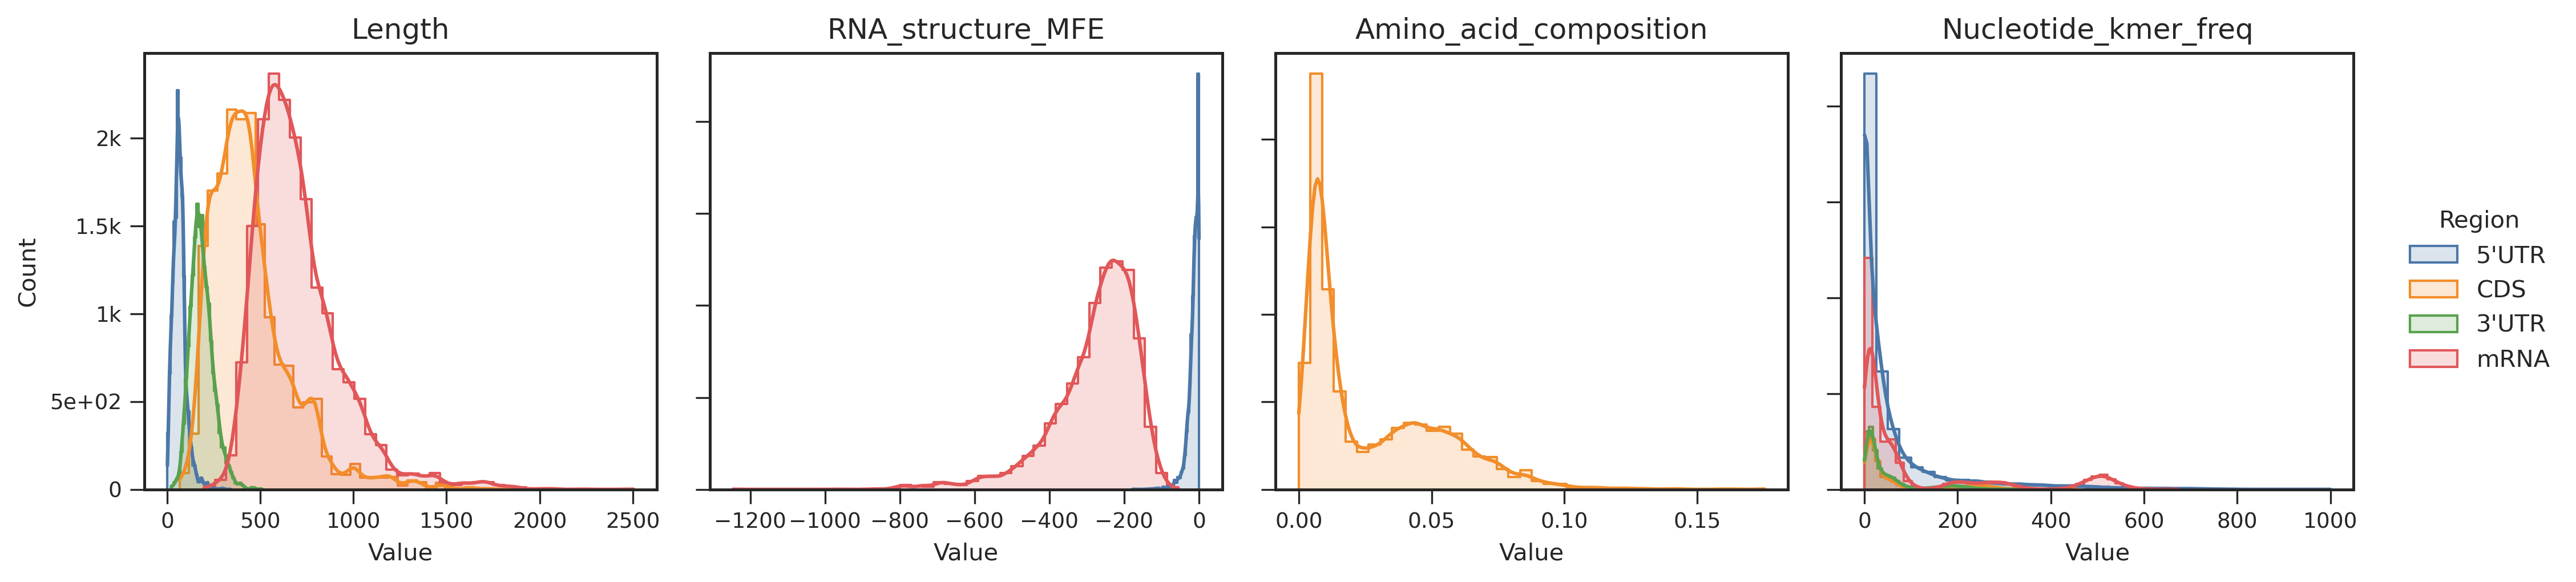

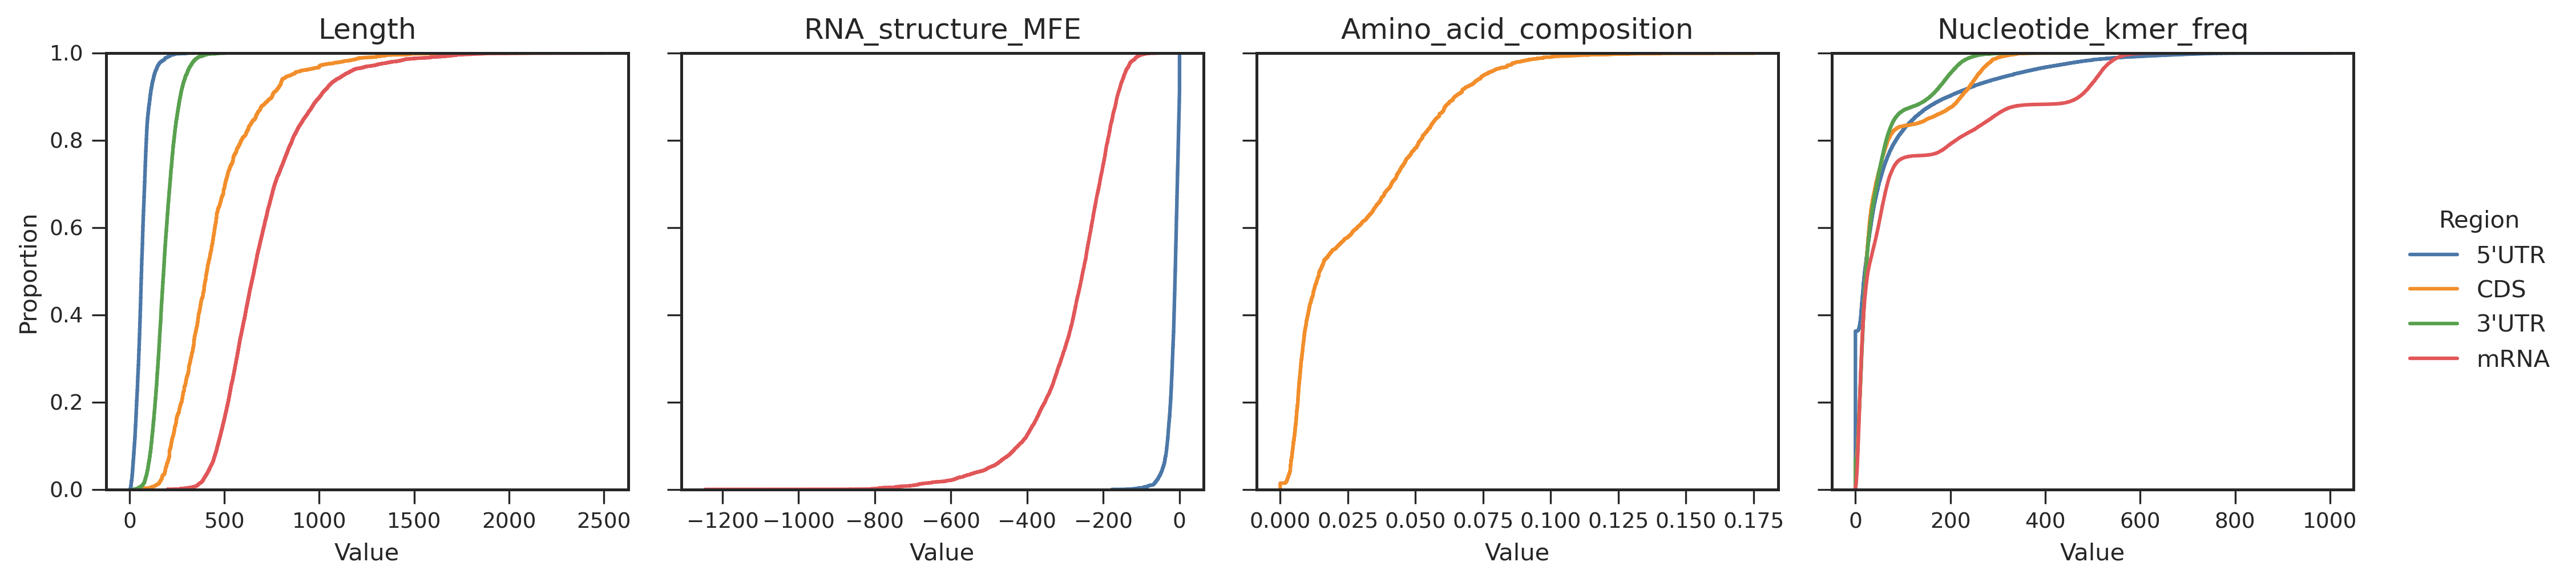

In [6]:
# ============================================
# Raw candidate-feature distributions
# ============================================

feature_type_order = [
    "Length",
    "RNA_structure_MFE",
    "Amino_acid_composition",
    "Nucleotide_kmer_freq",
]

region_order = ["5'UTR", "CDS", "3'UTR", "mRNA"]

region_colors = {
    "5'UTR": "#4C78A8",
    "CDS": "#F28E2B",
    "3'UTR": "#59A14F",
    "mRNA": "#E15759",
}

plot_df = candidate_long_df.copy()
plot_df["Feature_type"] = pd.Categorical(plot_df["Feature_type"], categories=feature_type_order, ordered=True)
plot_df["Region"] = pd.Categorical(plot_df["Region"], categories=region_order, ordered=True)

# --------------------------------------------
# Histogram + KDE
# --------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), dpi=_PLOT_CFG["dpi"])

for ax, feature_type in zip(axes, feature_type_order):
    temp = plot_df[plot_df["Feature_type"] == feature_type]

    for region in region_order:
        values = temp.loc[temp["Region"] == region, "Value"].dropna()
        if values.empty:
            continue

        sns.histplot(
            values,
            bins=40,
            stat="count",
            element="step",
            fill=True,
            alpha=0.20,
            kde=True,
            color=region_colors[region],
            label=region,
            ax=ax,
        )

    ax.set_title(feature_type)
    format_axis(ax, xlabel="Value", ylabel="Count" if ax is axes[0] else "", compact_ticks=("y",))

    if ax is not axes[0]:
        ax.tick_params(labelleft=False)

handles, labels = axes[-1].get_legend_handles_labels()

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.legend(handles, labels, title="Region", frameon=False, loc="center left", bbox_to_anchor=(1.00, 0.5))

plt.tight_layout()
plt.show()

# --------------------------------------------
# ECDF
# --------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), dpi=_PLOT_CFG["dpi"])

for ax, feature_type in zip(axes, feature_type_order):
    temp = plot_df[plot_df["Feature_type"] == feature_type]

    for region in region_order:
        values = temp.loc[temp["Region"] == region, "Value"].dropna()
        if values.empty:
            continue

        sns.ecdfplot(
            x=values,
            color=region_colors[region],
            linewidth=1.5,
            label=region,
            ax=ax,
        )

    ax.set_title(feature_type)
    format_axis(ax, xlabel="Value", ylabel="Proportion" if ax is axes[0] else "")

    if ax is not axes[0]:
        ax.tick_params(labelleft=False)

handles, labels = axes[-1].get_legend_handles_labels()

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.legend(handles, labels, title="Region", frameon=False, loc="center left", bbox_to_anchor=(1.00, 0.5))

plt.tight_layout()
plt.show()

In [7]:
# ============================================
# Raw feature-feature dependence (Spearman)
# ============================================

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from statsmodels.stats.multitest import multipletests

raw_corr_matrices = {}
raw_pvalue_matrices = {}
raw_fdr_matrices = {}
raw_feature_orders = {}

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]

    feature_df = (
        candidate_master_df
        .loc[candidate_master_df["Species"] == species, candidate_features]
        .copy()
    )

    corr = feature_df.corr(method="spearman")

    pval = pd.DataFrame(
        np.ones(corr.shape),
        index=corr.index,
        columns=corr.columns,
    )

    for i in range(len(candidate_features)):
        for j in range(i + 1, len(candidate_features)):
            r, p = stats.spearmanr(
                feature_df.iloc[:, i],
                feature_df.iloc[:, j],
                nan_policy="omit",
            )
            pval.iat[i, j] = p
            pval.iat[j, i] = p

    tril = np.tril_indices_from(pval, k=-1)

    fdr = np.ones_like(pval.values)

    _, qvals, _, _ = multipletests(
        pval.values[tril],
        method="fdr_bh",
    )

    fdr[tril] = qvals
    fdr[(tril[1], tril[0])] = qvals

    fdr = pd.DataFrame(
        fdr,
        index=pval.index,
        columns=pval.columns,
    )

    distance = 1 - np.abs(corr)
    np.fill_diagonal(distance.values, 0)

    linkage_matrix = linkage(
        squareform(distance),
        method="average",
    )

    order = corr.index[leaves_list(linkage_matrix)].tolist()

    raw_corr_matrices[species_key] = corr
    raw_pvalue_matrices[species_key] = pval
    raw_fdr_matrices[species_key] = fdr
    raw_feature_orders[species_key] = order

    print(
        f"{species_key}: "
        f"{corr.shape[0]} features, "
        f"{(fdr.values < 0.05).sum() // 2} significant pairs"
    )

AT21: 61 features, 1425 significant pairs
NB21: 61 features, 1368 significant pairs
OS21: 61 features, 1488 significant pairs


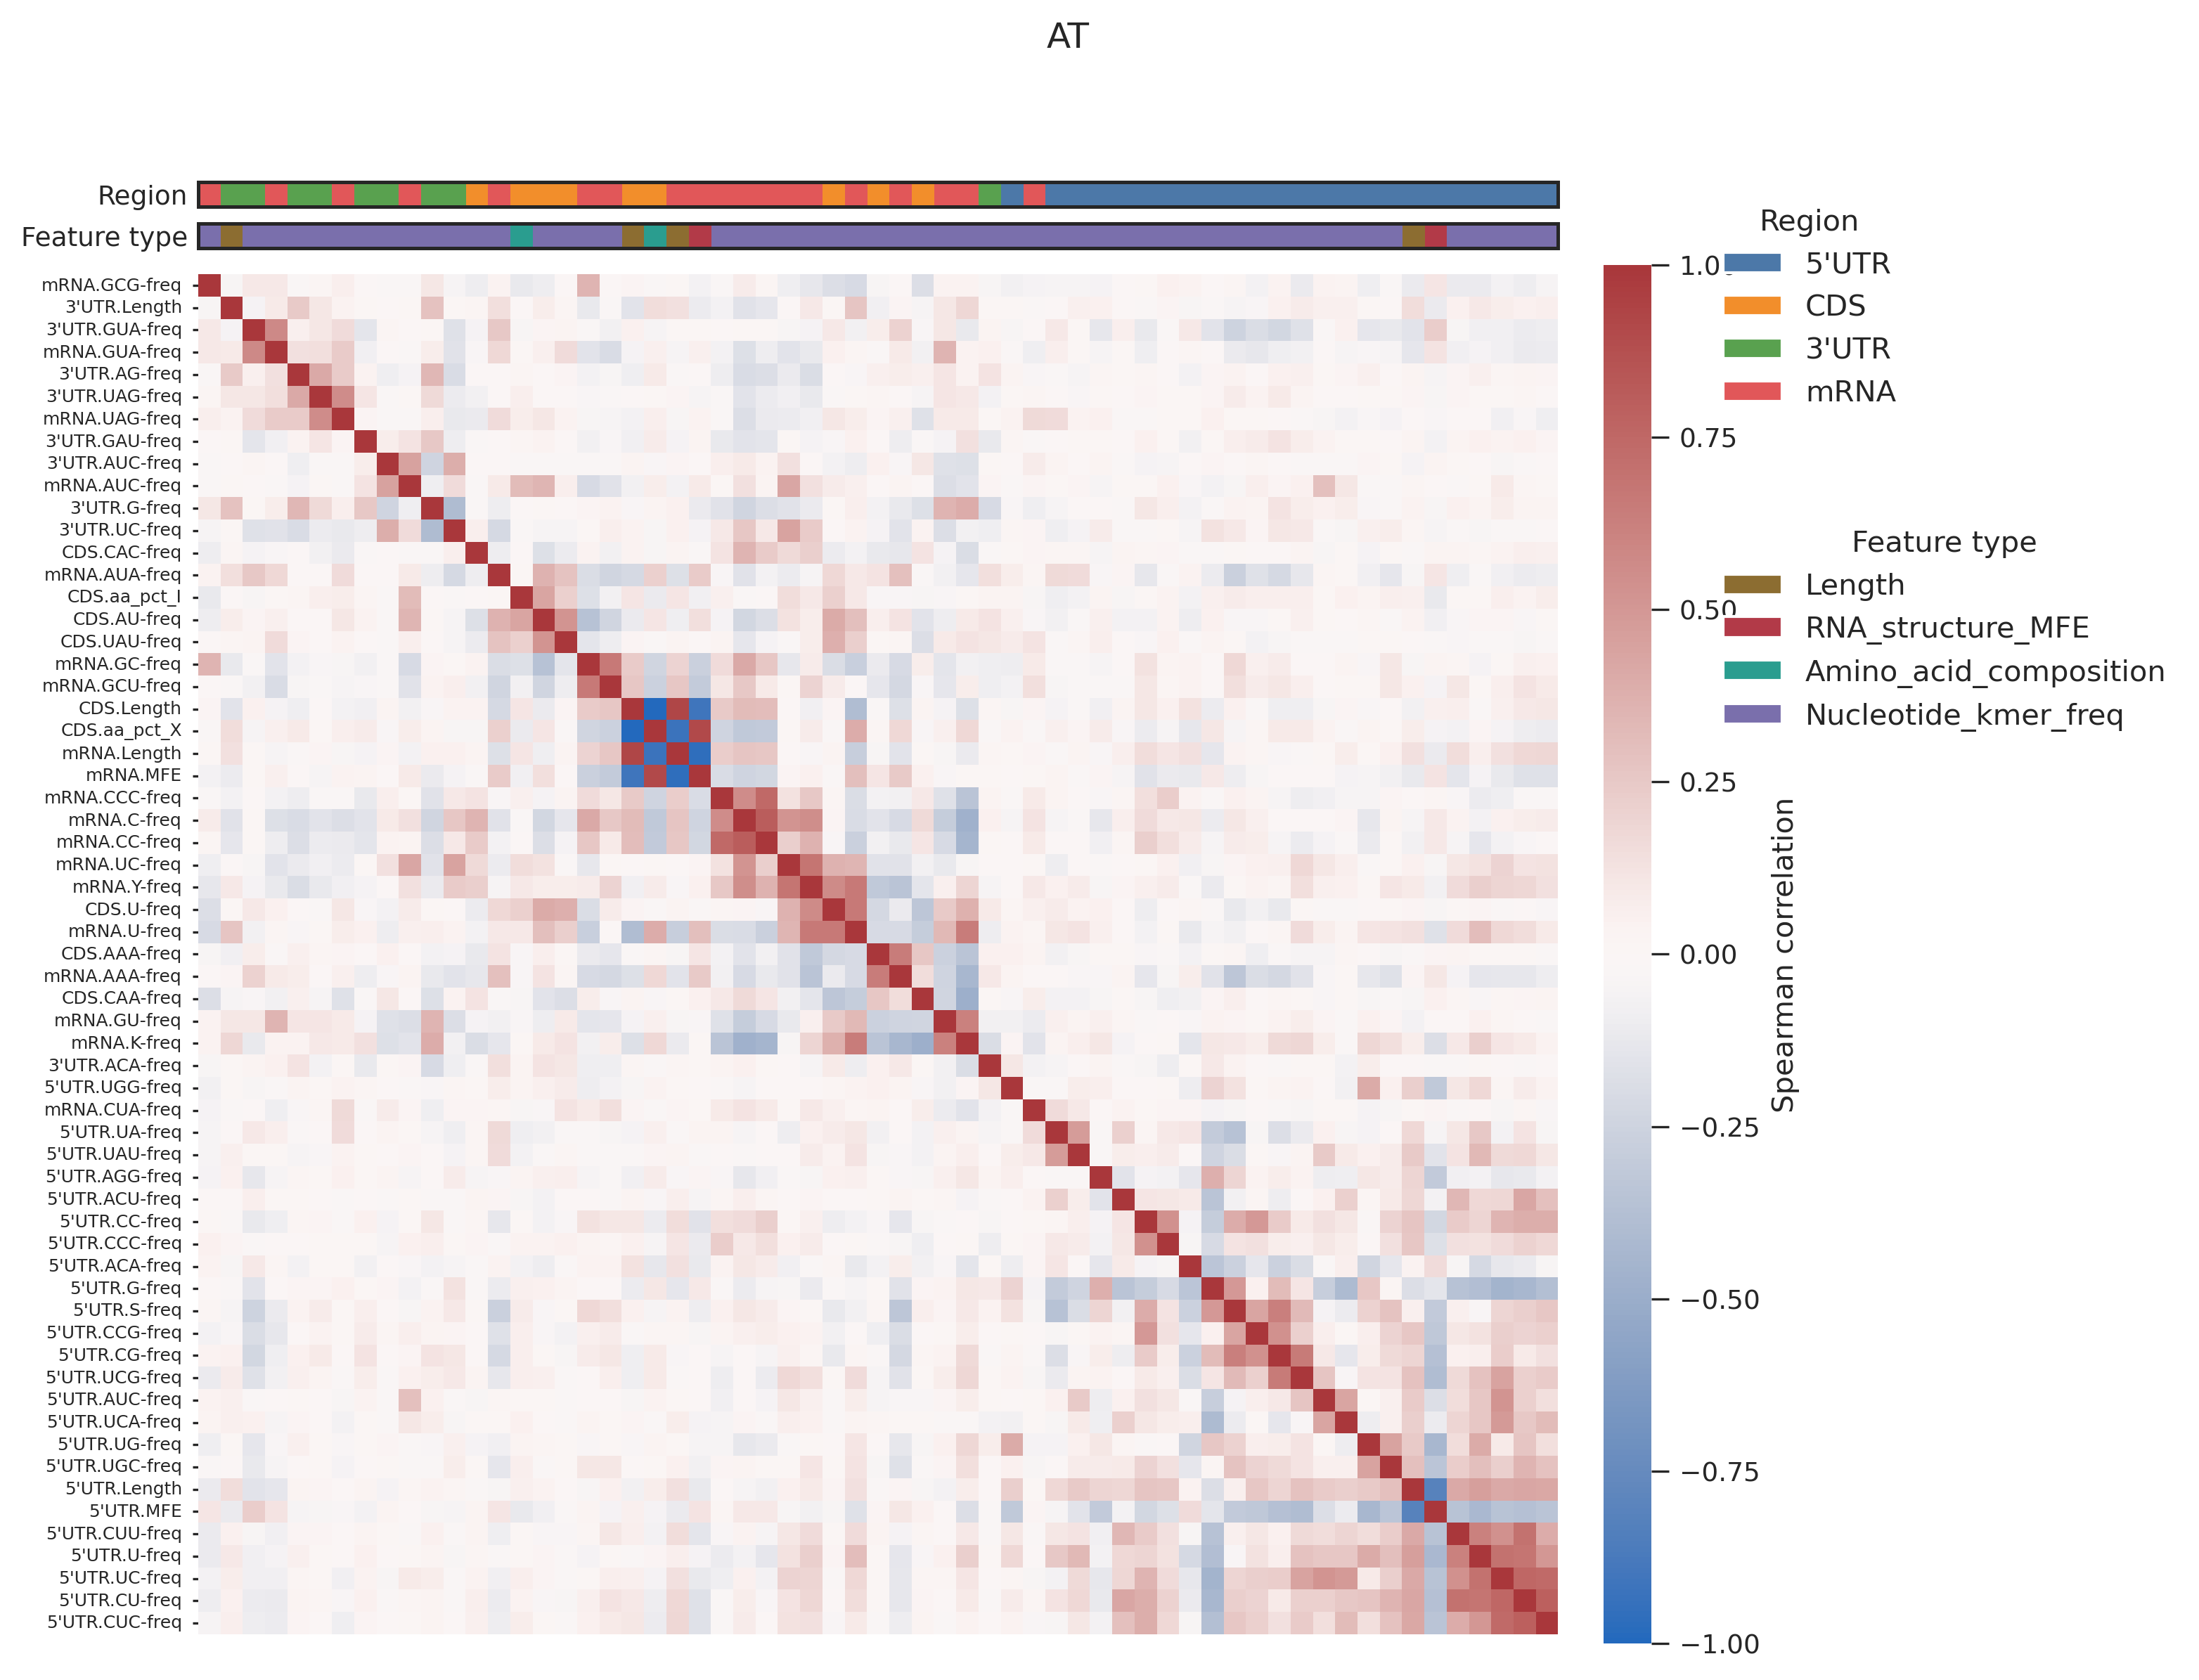

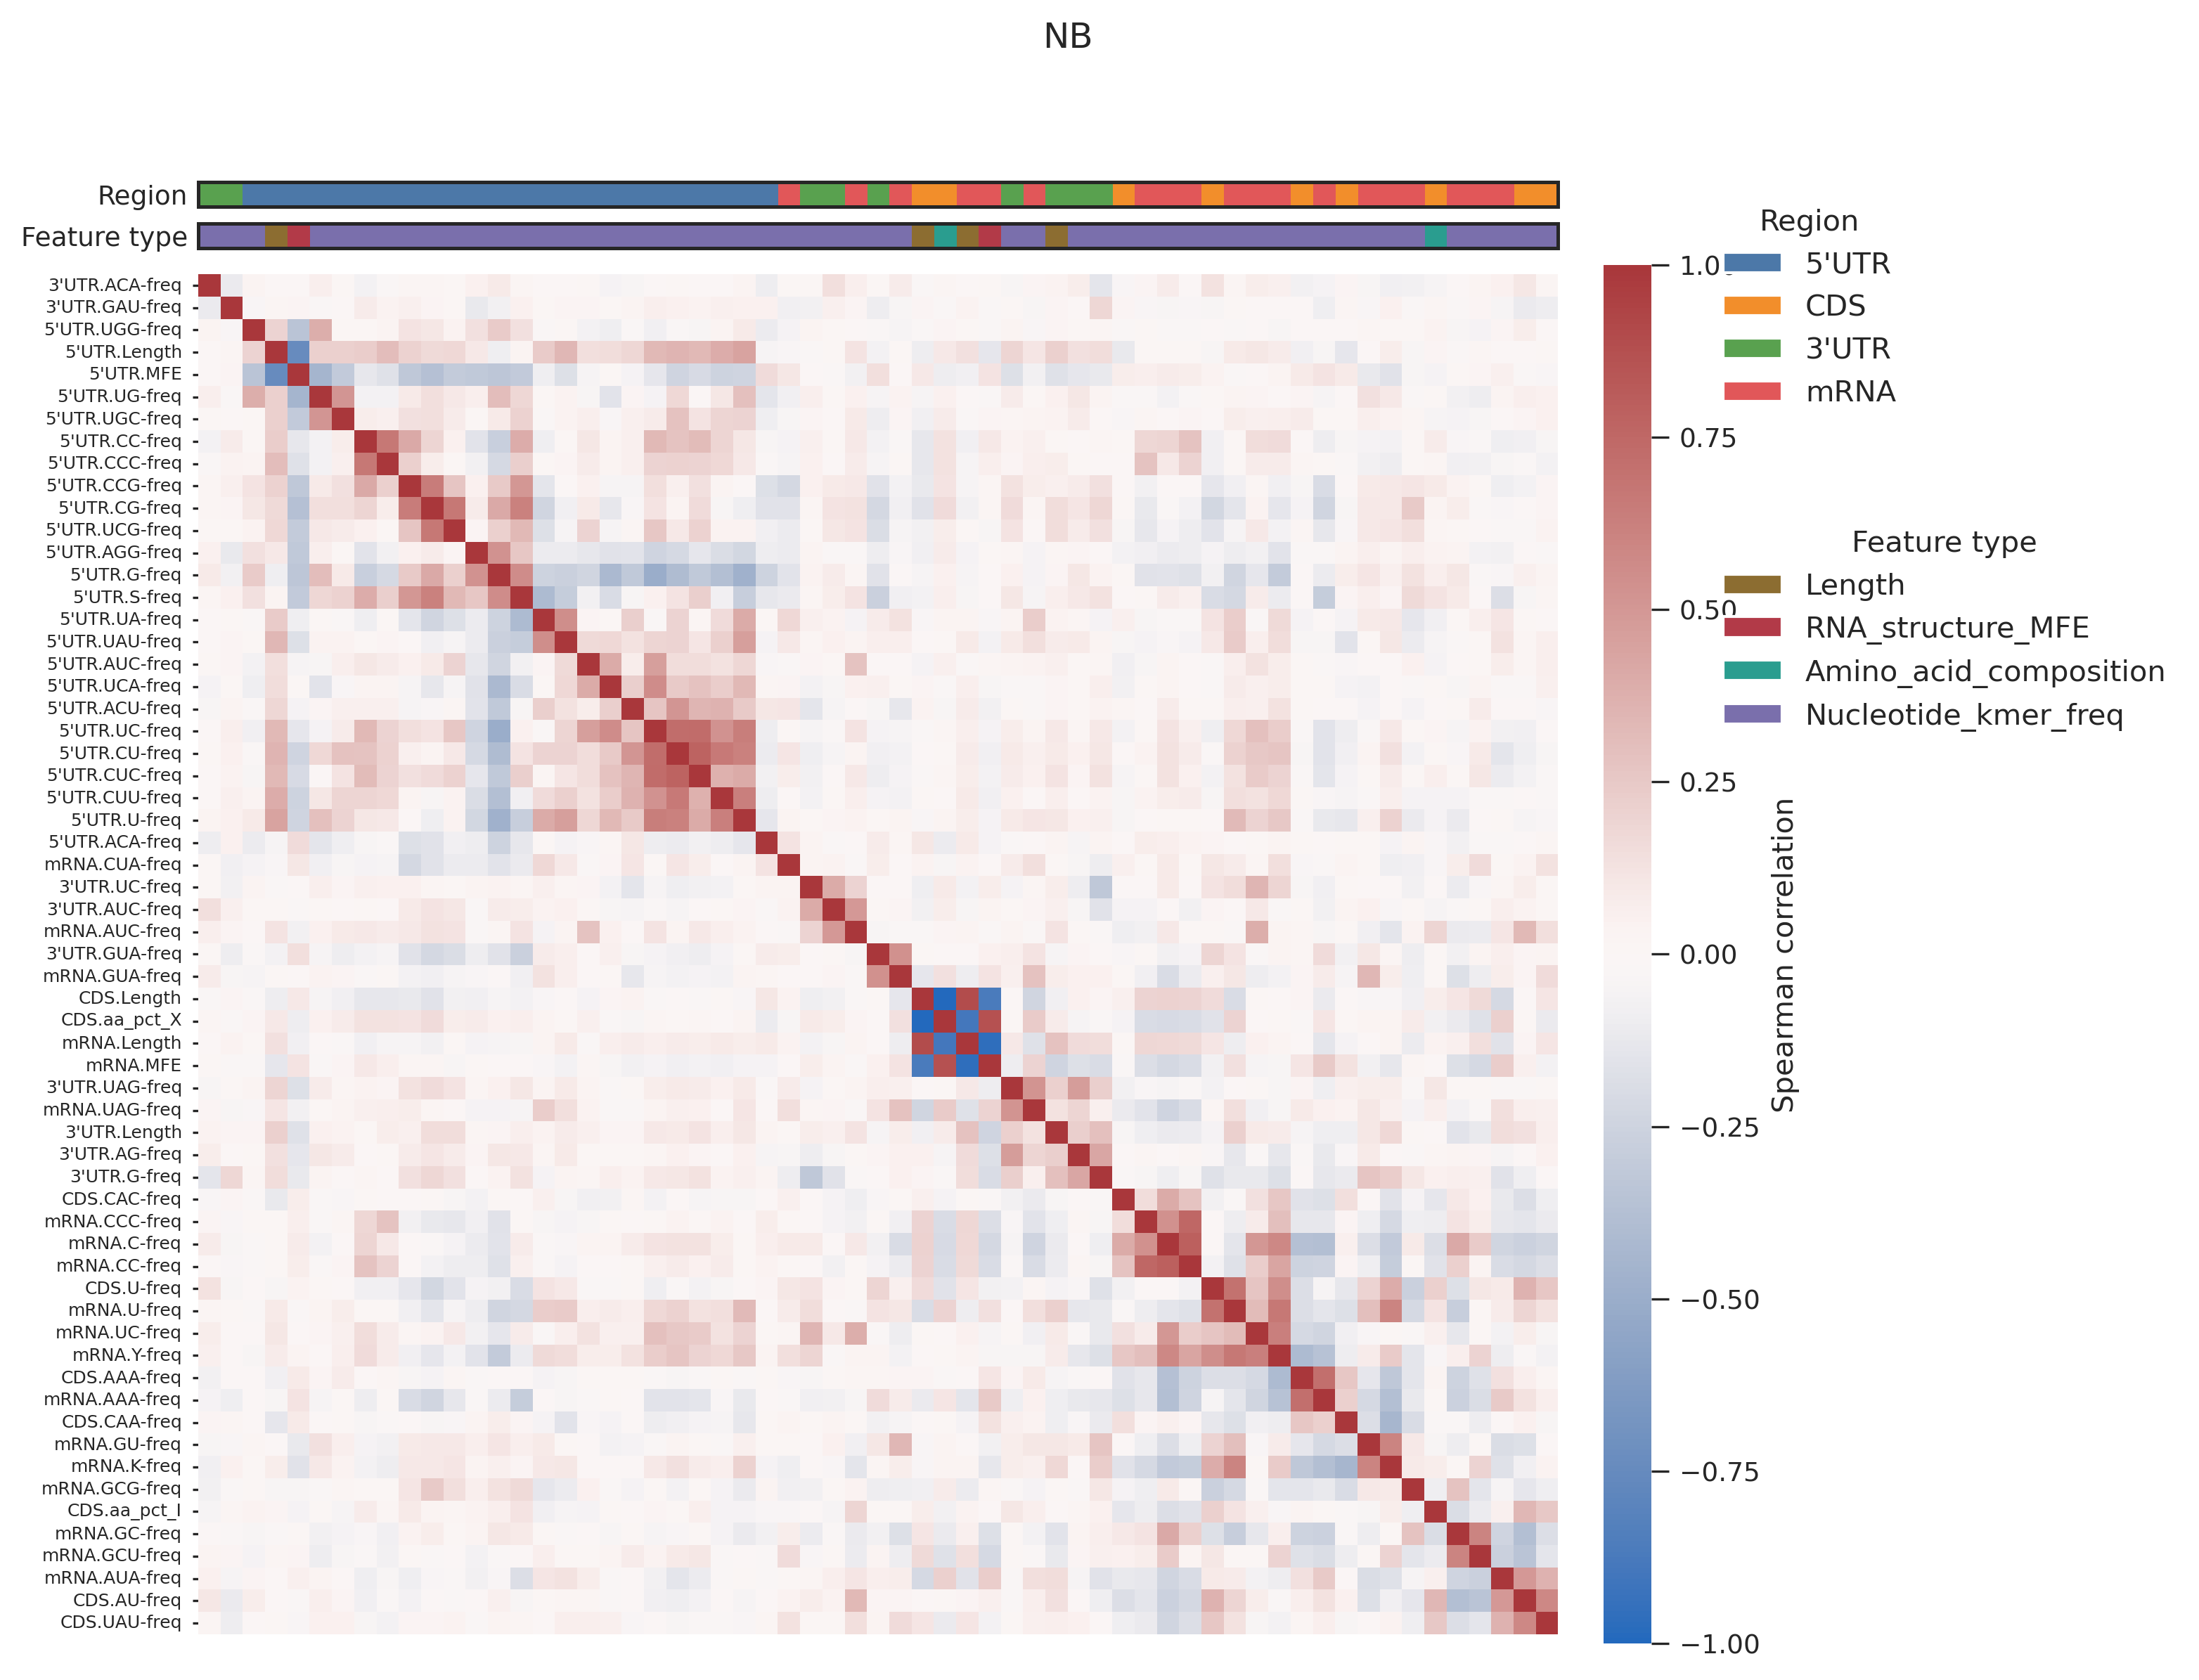

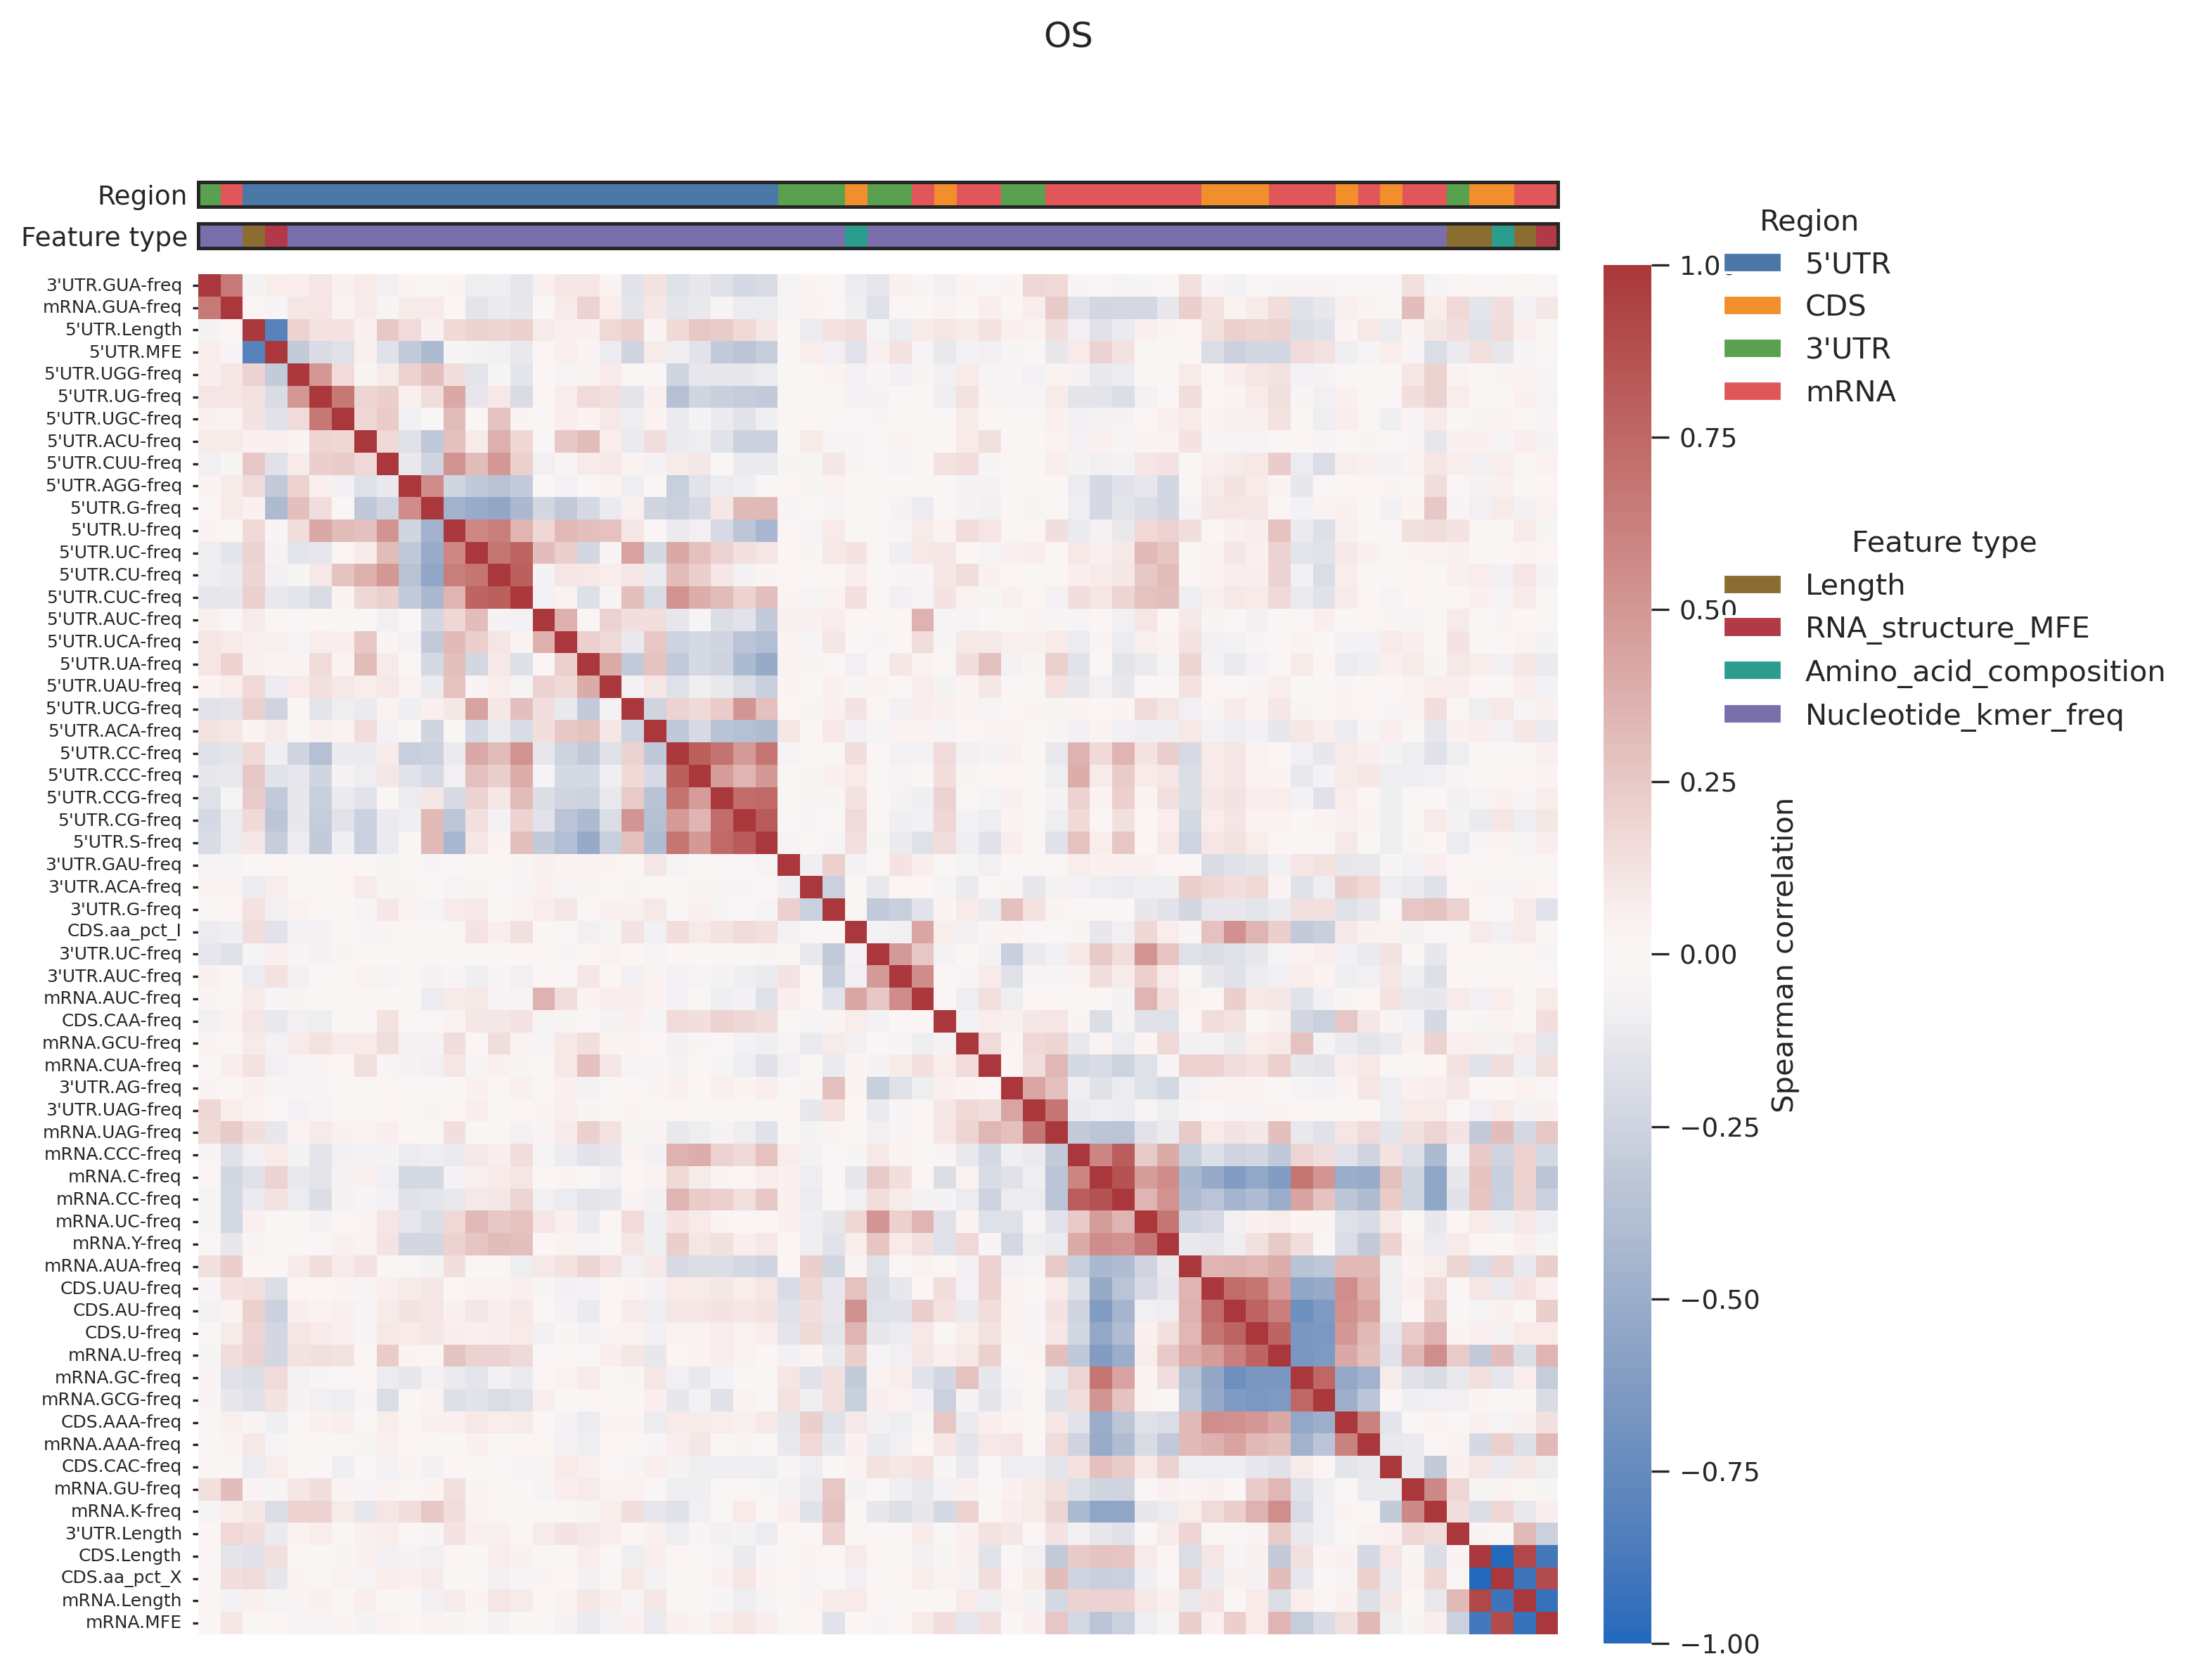

In [8]:
# ============================================
# Raw feature-feature dependence
# Spearman correlation heatmaps
# ============================================

from matplotlib.patches import Patch

region_colors = {
    "5'UTR": "#4C78A8",
    "CDS": "#F28E2B",
    "3'UTR": "#59A14F",
    "mRNA": "#E15759",
}

feature_type_colors = {
    "Length": "#8C6D31",
    "RNA_structure_MFE": "#B23A48",
    "Amino_acid_composition": "#2A9D8F",
    "Nucleotide_kmer_freq": "#7A6FAC",
}

region_handles = [Patch(facecolor=color, label=label) for label, color in region_colors.items()]
type_handles = [Patch(facecolor=color, label=label) for label, color in feature_type_colors.items()]

for species_key in SPECIES:
    species = SPECIES_INFO[species_key]["label"]
    order = raw_feature_orders[species_key]
    corr_ordered = raw_corr_matrices[species_key].loc[order, order]

    region_values = feature_meta_lookup.loc[order, "Region"]
    type_values = feature_meta_lookup.loc[order, "Feature_type"]

    region_rgba = np.array([mpl.colors.to_rgba(region_colors[x]) for x in region_values])[None, :, :]
    type_rgba = np.array([mpl.colors.to_rgba(feature_type_colors[x]) for x in type_values])[None, :, :]

    fig = plt.figure(figsize=(11, 9), dpi=_PLOT_CFG["dpi"])
    gs = GridSpec(3, 3, figure=fig, width_ratios=[1, 0.035, 0.22], height_ratios=[0.018, 0.018, 1], hspace=0.035, wspace=0.08)

    ax_region = fig.add_subplot(gs[0, 0])
    ax_type = fig.add_subplot(gs[1, 0])
    ax_heat = fig.add_subplot(gs[2, 0])
    ax_cbar = fig.add_subplot(gs[2, 1])
    ax_legend = fig.add_subplot(gs[:, 2])

    ax_region.imshow(region_rgba, aspect="auto")
    ax_type.imshow(type_rgba, aspect="auto")

    for ax, label in [(ax_region, "Region"), (ax_type, "Feature type")]:
        ax.set_xticks([])
        ax.set_yticks([0])
        ax.set_yticklabels([label])
        ax.tick_params(axis="y", length=0)

    sns.heatmap(
        corr_ordered,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        xticklabels=False,
        yticklabels=True,
        cbar_ax=ax_cbar,
        cbar_kws={"label": "Spearman correlation"},
        ax=ax_heat,
    )

    ax_heat.set_xlabel("")
    ax_heat.set_ylabel("")
    ax_heat.tick_params(axis="y", labelrotation=0, labelsize=6, length=2)

    ax_legend.axis("off")
    region_legend = ax_legend.legend(handles=region_handles, title="Region", frameon=False, loc="upper left", bbox_to_anchor=(0, 1))
    ax_legend.add_artist(region_legend)
    ax_legend.legend(handles=type_handles, title="Feature type", frameon=False, loc="upper left", bbox_to_anchor=(0, 0.78))

    fig.suptitle(species, y=0.965)

    plt.show()

In [9]:
# ============================================
# Model feature-feature dependence (Pearson)
# ============================================

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from scipy import stats
from statsmodels.stats.multitest import multipletests

model_corr_matrices = {}
model_pvalue_matrices = {}
model_fdr_matrices = {}
model_feature_orders = {}

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]

    feature_df = (
        candidate_model_master_df
        .loc[
            candidate_model_master_df["Species"] == species,
            candidate_features,
        ]
        .copy()
    )

    corr = feature_df.corr(method="pearson")

    pval = pd.DataFrame(
        np.ones(corr.shape),
        index=corr.index,
        columns=corr.columns,
    )

    for i in range(len(candidate_features)):
        for j in range(i + 1, len(candidate_features)):
            r, p = stats.pearsonr(
                feature_df.iloc[:, i],
                feature_df.iloc[:, j],
            )
            pval.iat[i, j] = p
            pval.iat[j, i] = p

    tril = np.tril_indices_from(pval, k=-1)

    fdr = np.ones_like(pval.values)

    _, qvals, _, _ = multipletests(
        pval.values[tril],
        method="fdr_bh",
    )

    fdr[tril] = qvals
    fdr[(tril[1], tril[0])] = qvals

    fdr = pd.DataFrame(
        fdr,
        index=pval.index,
        columns=pval.columns,
    )

    distance = 1 - np.abs(corr)
    np.fill_diagonal(distance.values, 0)

    linkage_matrix = linkage(
        squareform(distance),
        method="average",
    )

    order = corr.index[leaves_list(linkage_matrix)].tolist()

    model_corr_matrices[species_key] = corr
    model_pvalue_matrices[species_key] = pval
    model_fdr_matrices[species_key] = fdr
    model_feature_orders[species_key] = order

    n_sig = (fdr.values[np.tril_indices_from(fdr, k=-1)] < 0.05).sum()

    print(
        f"{species}: "
        f"{corr.shape[0]} features | "
        f"{n_sig} significant pairs"
    )

AT: 61 features | 1431 significant pairs
NB: 61 features | 1399 significant pairs
OS: 61 features | 1473 significant pairs


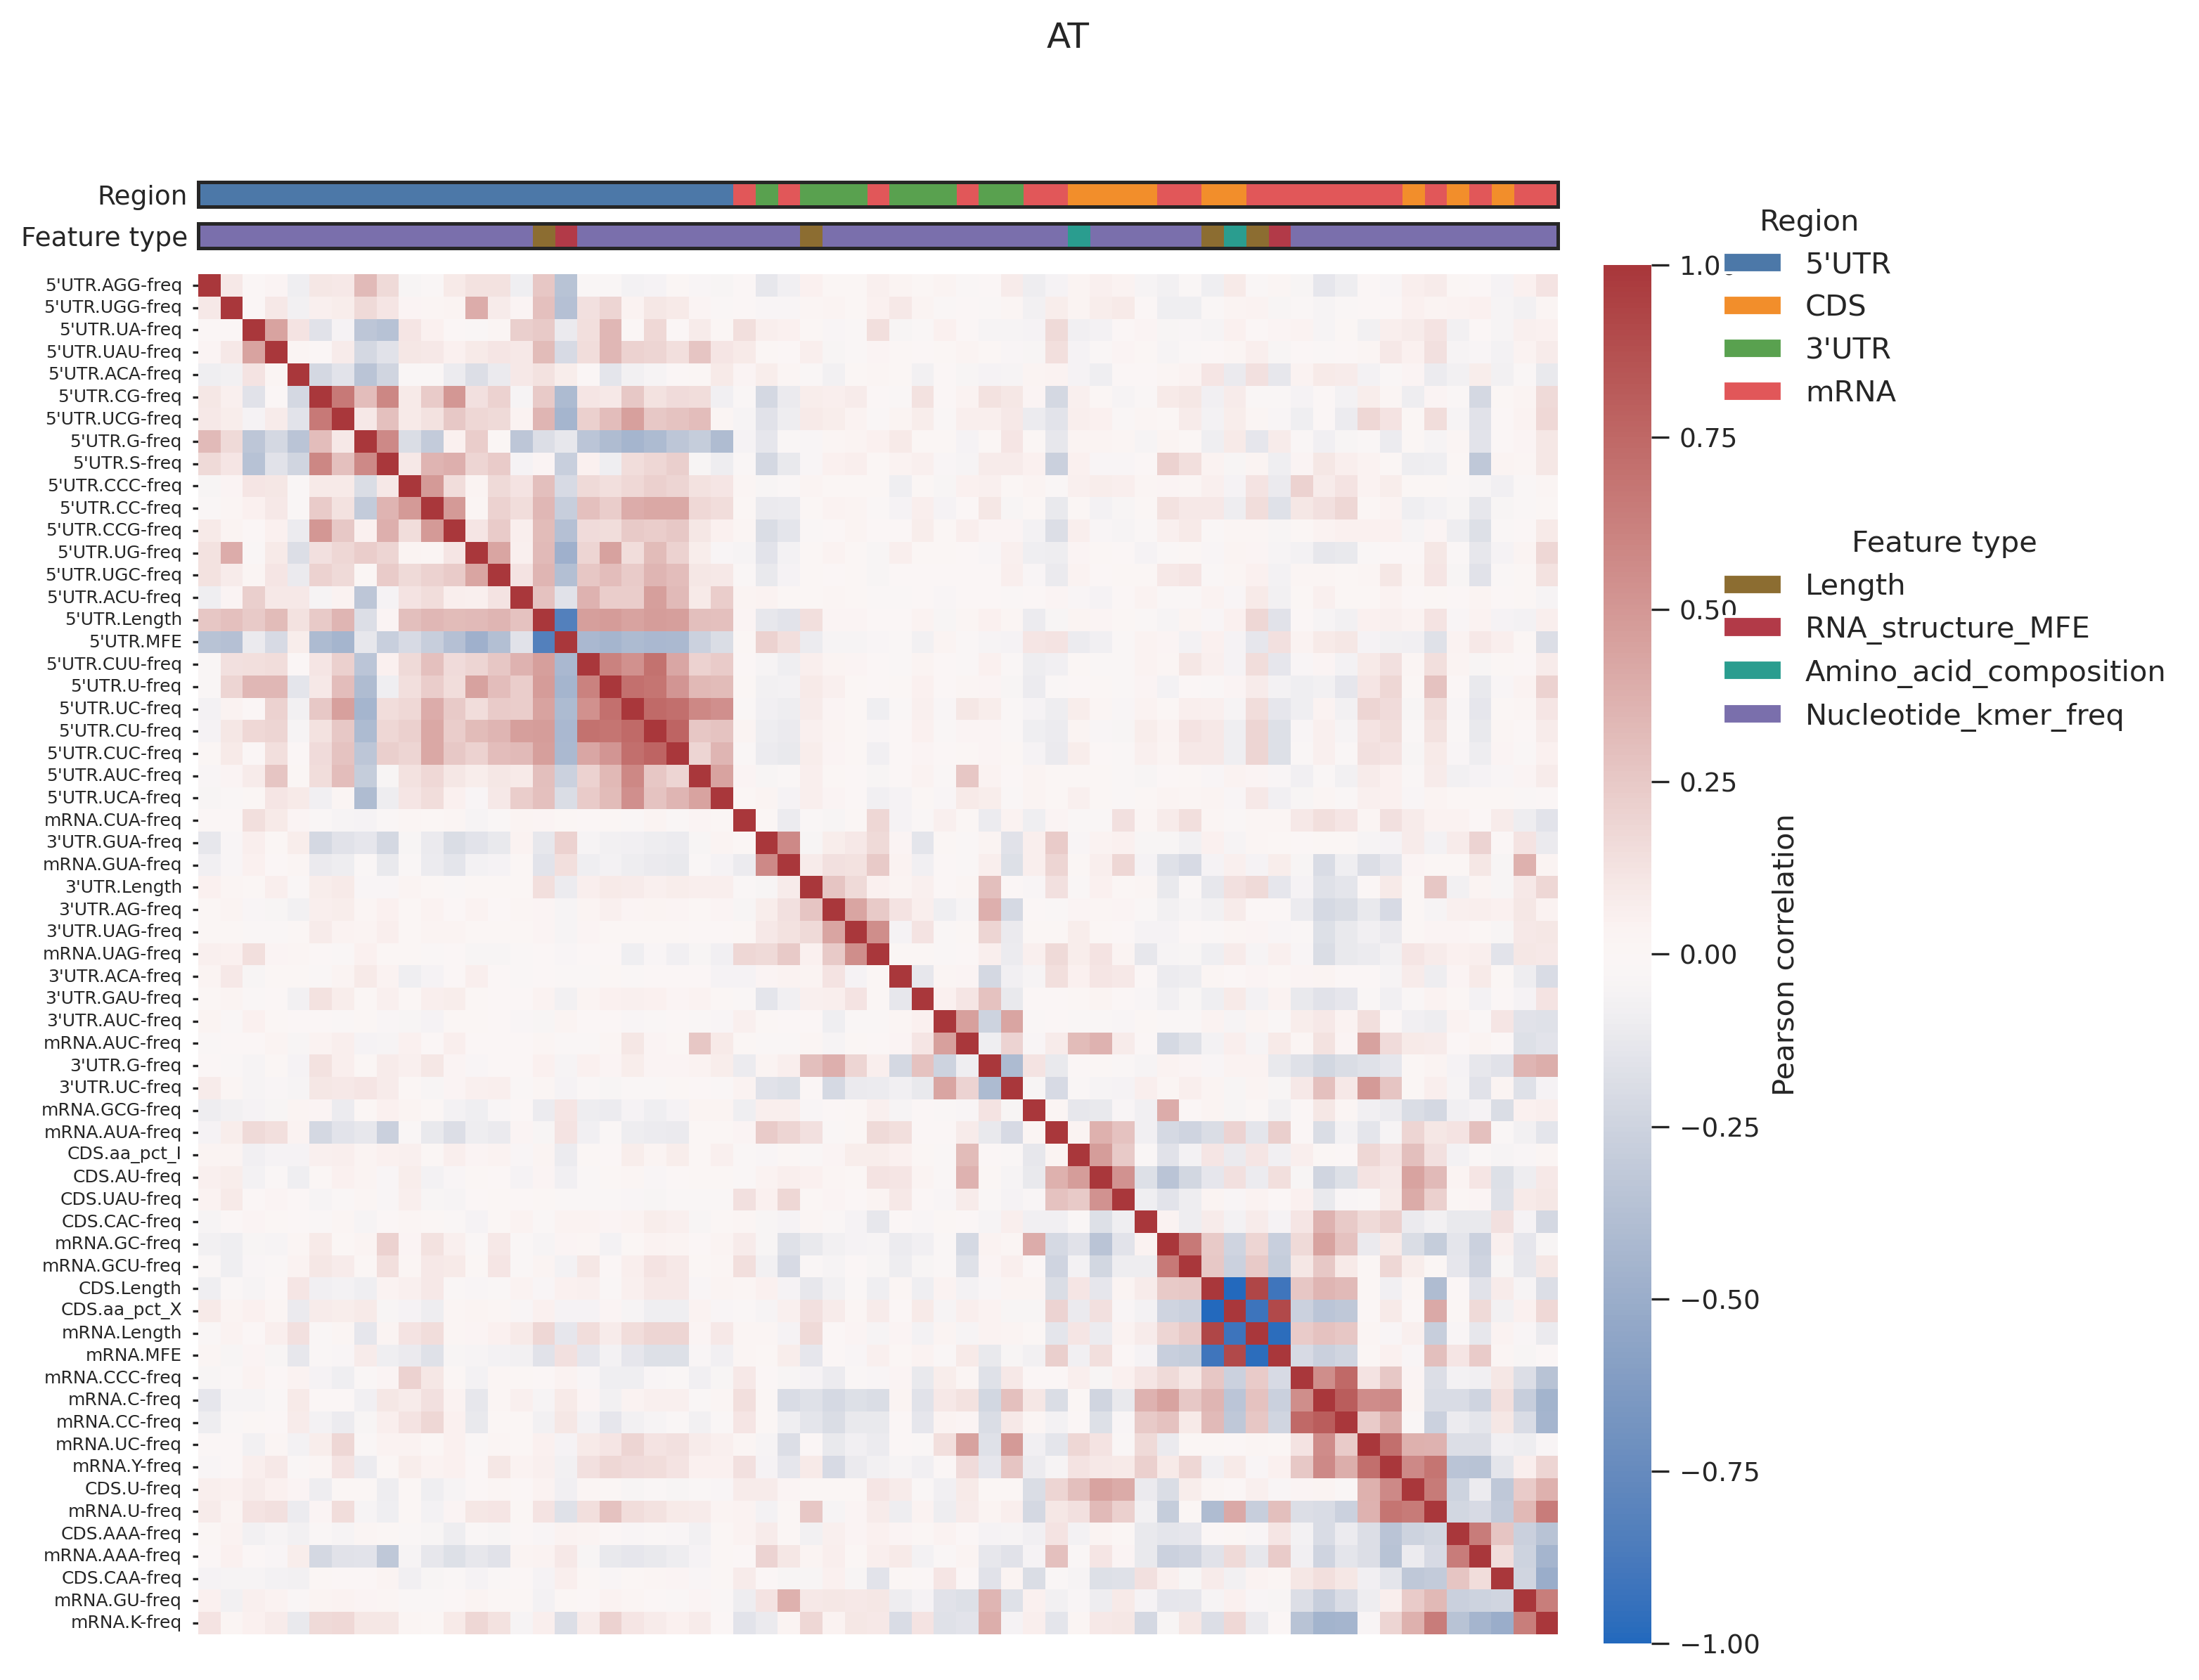

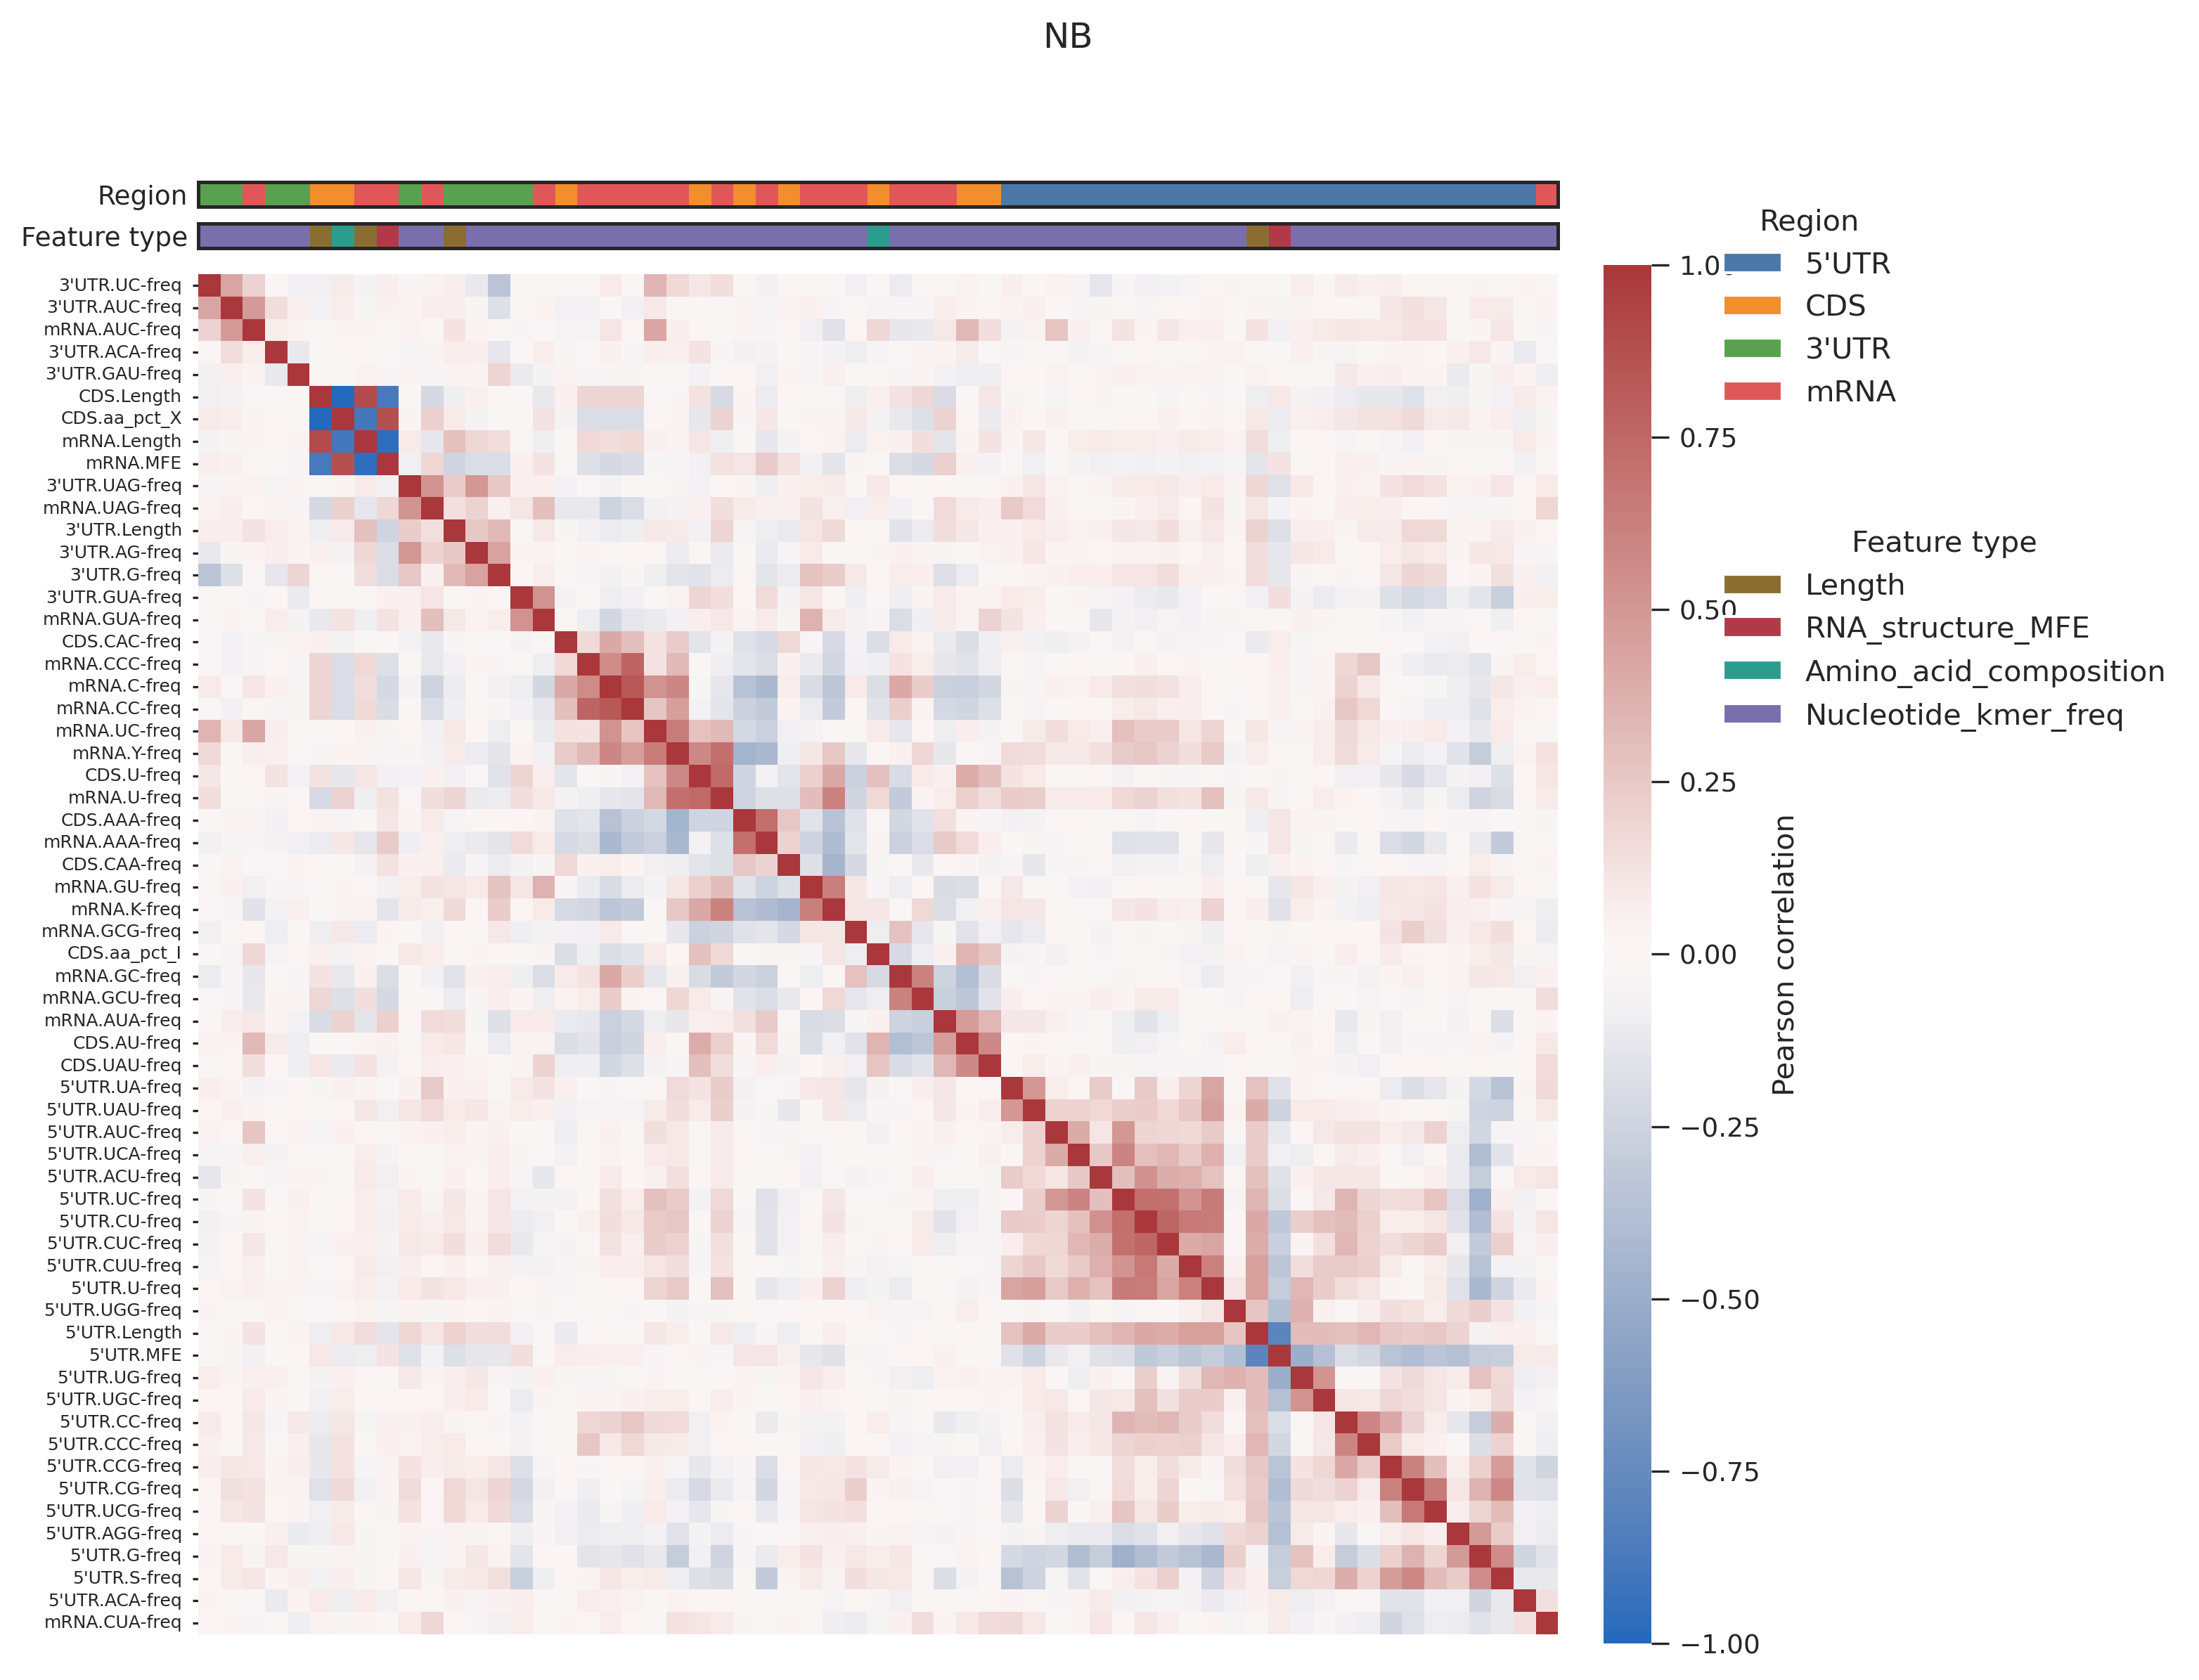

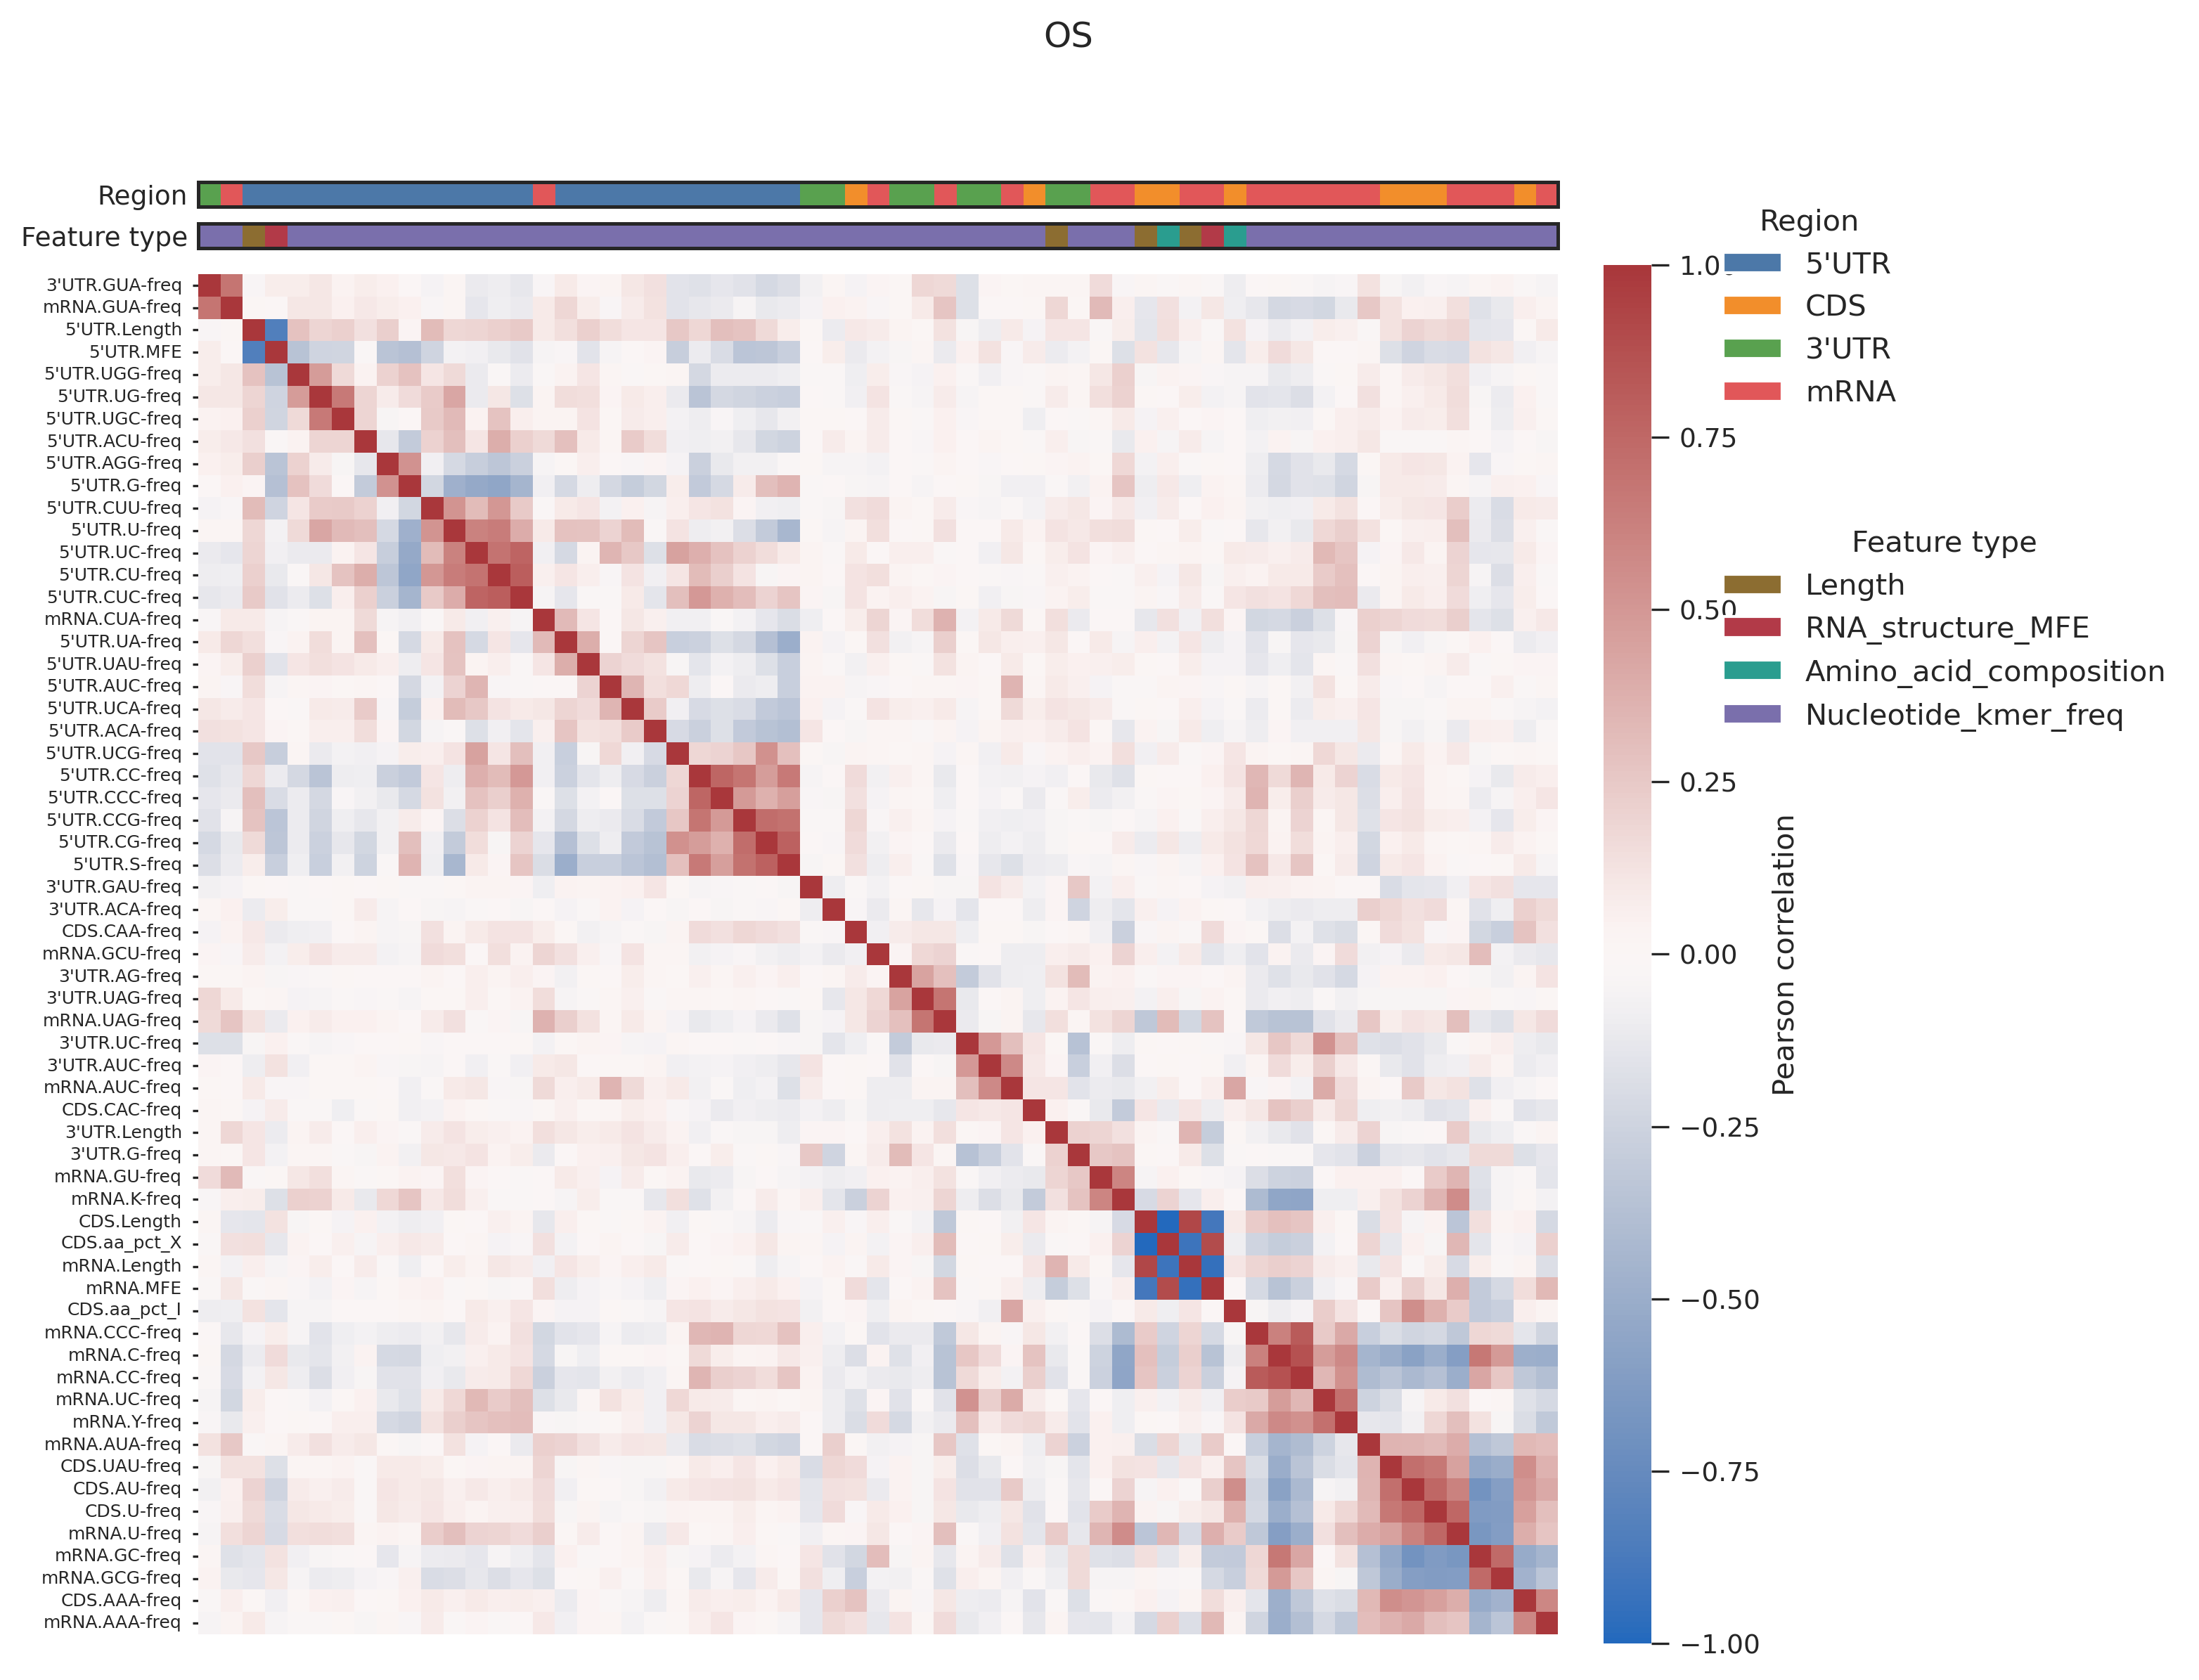

In [10]:
# ============================================
# Model feature-feature dependence
# Pearson correlation heatmaps
# ============================================

from matplotlib.patches import Patch

region_colors = {
    "5'UTR": "#4C78A8",
    "CDS": "#F28E2B",
    "3'UTR": "#59A14F",
    "mRNA": "#E15759",
}

feature_type_colors = {
    "Length": "#8C6D31",
    "RNA_structure_MFE": "#B23A48",
    "Amino_acid_composition": "#2A9D8F",
    "Nucleotide_kmer_freq": "#7A6FAC",
}

region_handles = [Patch(facecolor=c, label=l) for l, c in region_colors.items()]
type_handles = [Patch(facecolor=c, label=l) for l, c in feature_type_colors.items()]

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]
    order = model_feature_orders[species_key]
    corr_ordered = model_corr_matrices[species_key].loc[order, order]

    region_values = feature_meta_lookup.loc[order, "Region"]
    type_values = feature_meta_lookup.loc[order, "Feature_type"]

    region_rgba = np.array([mpl.colors.to_rgba(region_colors[x]) for x in region_values])[None, :, :]
    type_rgba = np.array([mpl.colors.to_rgba(feature_type_colors[x]) for x in type_values])[None, :, :]

    fig = plt.figure(figsize=(11, 9), dpi=_PLOT_CFG["dpi"])

    gs = GridSpec(
        3, 3, figure=fig,
        width_ratios=[1, 0.035, 0.22],
        height_ratios=[0.018, 0.018, 1],
        hspace=0.035,
        wspace=0.08,
    )

    ax_region = fig.add_subplot(gs[0, 0])
    ax_type = fig.add_subplot(gs[1, 0])
    ax_heat = fig.add_subplot(gs[2, 0])
    ax_cbar = fig.add_subplot(gs[2, 1])
    ax_legend = fig.add_subplot(gs[:, 2])

    ax_region.imshow(region_rgba, aspect="auto")
    ax_type.imshow(type_rgba, aspect="auto")

    for ax, label in [(ax_region, "Region"), (ax_type, "Feature type")]:
        ax.set_xticks([])
        ax.set_yticks([0])
        ax.set_yticklabels([label])
        ax.tick_params(axis="y", length=0)

    sns.heatmap(
        corr_ordered,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        xticklabels=False,
        yticklabels=True,
        cbar_ax=ax_cbar,
        cbar_kws={"label": "Pearson correlation"},
        ax=ax_heat,
    )

    ax_heat.set_xlabel("")
    ax_heat.set_ylabel("")
    ax_heat.tick_params(axis="y", labelrotation=0, labelsize=6, length=2)

    ax_legend.axis("off")

    legend_region = ax_legend.legend(handles=region_handles, title="Region", frameon=False,
                                     loc="upper left", bbox_to_anchor=(0, 1))
    ax_legend.add_artist(legend_region)

    ax_legend.legend(handles=type_handles, title="Feature type", frameon=False,
                     loc="upper left", bbox_to_anchor=(0, 0.78))

    fig.suptitle(species, y=0.965)

    plt.show()

In [11]:
# ============================================
# Extract strongest feature-feature associations
# ============================================

def extract_feature_pairs(corr_dict, pval_dict, fdr_dict, method):

    rows = []

    for species_key in SPECIES:

        species = SPECIES_INFO[species_key]["label"]

        corr = corr_dict[species_key]
        pval = pval_dict[species_key]
        fdr = fdr_dict[species_key]

        for i, f1 in enumerate(candidate_features):
            for j in range(i + 1, len(candidate_features)):

                f2 = candidate_features[j]

                rows.append({
                    "Method": method,
                    "Species": species,
                    "Feature_1": f1,
                    "Feature_2": f2,
                    "Region_1": feature_meta_lookup.loc[f1, "Region"],
                    "Region_2": feature_meta_lookup.loc[f2, "Region"],
                    "Feature_type_1": feature_meta_lookup.loc[f1, "Feature_type"],
                    "Feature_type_2": feature_meta_lookup.loc[f2, "Feature_type"],
                    "Correlation": corr.loc[f1, f2],
                    "Abs_correlation": abs(corr.loc[f1, f2]),
                    "P_value": pval.loc[f1, f2],
                    "FDR": fdr.loc[f1, f2],
                })

    pair_df = (
        pd.DataFrame(rows)
        .sort_values("Abs_correlation", ascending=False)
        .reset_index(drop=True)
    )

    return pair_df


raw_pair_df = extract_feature_pairs(
    raw_corr_matrices,
    raw_pvalue_matrices,
    raw_fdr_matrices,
    method="Spearman",
)

model_pair_df = extract_feature_pairs(
    model_corr_matrices,
    model_pvalue_matrices,
    model_fdr_matrices,
    method="Pearson",
)

print("Raw Spearman")
display(raw_pair_df.head(20))

print("Model Pearson")
display(model_pair_df.head(20))

Raw Spearman


,Method,Species,Feature_1,Feature_2,Region_1,Region_2,Feature_type_1,Feature_type_2,Correlation,Abs_correlation,P_value,FDR
0,Spearman,NB,CDS.Length,CDS.aa_pct_X,CDS,CDS,Length,Amino_acid_composition,-1.000000,1.000000,0.0,0.0
1,Spearman,OS,CDS.Length,CDS.aa_pct_X,CDS,CDS,Length,Amino_acid_composition,-1.000000,1.000000,0.0,0.0
2,Spearman,AT,CDS.Length,CDS.aa_pct_X,CDS,CDS,Length,Amino_acid_composition,-1.000000,1.000000,0.0,0.0
3,Spearman,AT,mRNA.Length,mRNA.MFE,mRNA,mRNA,Length,RNA_structure_MFE,-0.968306,0.968306,0.0,0.0
4,Spearman,NB,mRNA.Length,mRNA.MFE,mRNA,mRNA,Length,RNA_structure_MFE,-0.963658,0.963658,0.0,0.0
5,Spearman,OS,mRNA.Length,mRNA.MFE,mRNA,mRNA,Length,RNA_structure_MFE,-0.943709,0.943709,0.0,0.0
6,Spearman,AT,CDS.aa_pct_X,mRNA.Length,CDS,mRNA,Amino_acid_composition,Length,-0.923965,0.923965,0.0,0.0
7,Spearman,AT,CDS.Length,mRNA.Length,CDS,mRNA,Length,Length,0.923965,0.923965,0.0,0.0
8,Spearman,OS,CDS.Length,mRNA.Length,CDS,mRNA,Length,Length,0.921114,0.921114,0.0,0.0
9,Spearman,OS,CDS.aa_pct_X,mRNA.Length,CDS,mRNA,Amino_acid_composition,Length,-0.921114,0.921114,0.0,0.0


Model Pearson


,Method,Species,Feature_1,Feature_2,Region_1,Region_2,Feature_type_1,Feature_type_2,Correlation,Abs_correlation,P_value,FDR
0,Pearson,NB,CDS.Length,CDS.aa_pct_X,CDS,CDS,Length,Amino_acid_composition,-0.999312,0.999312,0.0,0.0
1,Pearson,OS,CDS.Length,CDS.aa_pct_X,CDS,CDS,Length,Amino_acid_composition,-0.998126,0.998126,0.0,0.0
2,Pearson,AT,CDS.Length,CDS.aa_pct_X,CDS,CDS,Length,Amino_acid_composition,-0.994750,0.994750,0.0,0.0
3,Pearson,AT,mRNA.Length,mRNA.MFE,mRNA,mRNA,Length,RNA_structure_MFE,-0.969913,0.969913,0.0,0.0
4,Pearson,NB,mRNA.Length,mRNA.MFE,mRNA,mRNA,Length,RNA_structure_MFE,-0.965486,0.965486,0.0,0.0
5,Pearson,OS,mRNA.Length,mRNA.MFE,mRNA,mRNA,Length,RNA_structure_MFE,-0.946961,0.946961,0.0,0.0
6,Pearson,AT,CDS.Length,mRNA.Length,CDS,mRNA,Length,Length,0.925665,0.925665,0.0,0.0
7,Pearson,OS,CDS.Length,mRNA.Length,CDS,mRNA,Length,Length,0.919613,0.919613,0.0,0.0
8,Pearson,AT,CDS.aa_pct_X,mRNA.Length,CDS,mRNA,Amino_acid_composition,Length,-0.919476,0.919476,0.0,0.0
9,Pearson,OS,CDS.aa_pct_X,mRNA.Length,CDS,mRNA,Amino_acid_composition,Length,-0.916441,0.916441,0.0,0.0


In [12]:
# ============================================
# Candidate feature–PR associations
# ============================================

from statsmodels.stats.multitest import multipletests

association_rows = []

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]
    df = candidate_master_df.loc[candidate_master_df["Species"] == species].copy()

    temp, pvals = [], []

    for feature in candidate_features:

        r, p = stats.spearmanr(df[feature], df["observed_raw"], nan_policy="omit")

        temp.append({
            "Species": species,
            "Feature": feature,
            "Region": feature_meta_lookup.loc[feature, "Region"],
            "Feature_type": feature_meta_lookup.loc[feature, "Feature_type"],
            "Spearman_r": r,
            "Abs_r": abs(r),
            "P_value": p,
        })

        pvals.append(p)

    _, qvals, _, _ = multipletests(pvals, method="fdr_bh")

    for row, q in zip(temp, qvals):
        row["FDR"] = q
        row["Direction"] = "Positive" if row["Spearman_r"] >= 0 else "Negative"

    association_rows.extend(temp)

association_df = (
    pd.DataFrame(association_rows)
    .sort_values(["Species", "Abs_r"], ascending=[True, False])
    .reset_index(drop=True)
)

print("Candidate feature–PR associations")
print(association_df.shape)

display(association_df.head(20))

Candidate feature–PR associations
(183, 9)


,Species,Feature,Region,Feature_type,Spearman_r,Abs_r,P_value,FDR,Direction
0,AT,CDS.U-freq,CDS,Nucleotide_kmer_freq,-0.206221,0.206221,2.705246e-69,1.650200e-67,Negative
1,AT,CDS.AU-freq,CDS,Nucleotide_kmer_freq,-0.205146,0.205146,1.408933e-68,4.297246e-67,Negative
2,AT,5'UTR.MFE,5'UTR,RNA_structure_MFE,0.171073,0.171073,6.184128e-48,1.257439e-46,Positive
3,AT,CDS.UAU-freq,CDS,Nucleotide_kmer_freq,-0.145280,0.145280,6.467855e-35,9.863479e-34,Negative
4,AT,5'UTR.S-freq,5'UTR,Nucleotide_kmer_freq,-0.140297,0.140297,1.181925e-32,1.441948e-31,Negative
5,AT,5'UTR.Length,5'UTR,Length,-0.132556,0.132556,2.670718e-29,2.715230e-28,Negative
6,AT,mRNA.Y-freq,mRNA,Nucleotide_kmer_freq,-0.123443,0.123443,1.336701e-25,1.164840e-24,Negative
7,AT,CDS.aa_pct_I,CDS,Amino_acid_composition,-0.121213,0.121213,9.781828e-25,7.458644e-24,Negative
8,AT,mRNA.Length,mRNA,Length,-0.118827,0.118827,7.907029e-24,5.359209e-23,Negative
9,AT,5'UTR.CU-freq,5'UTR,Nucleotide_kmer_freq,-0.118530,0.118530,1.022310e-23,6.236094e-23,Negative


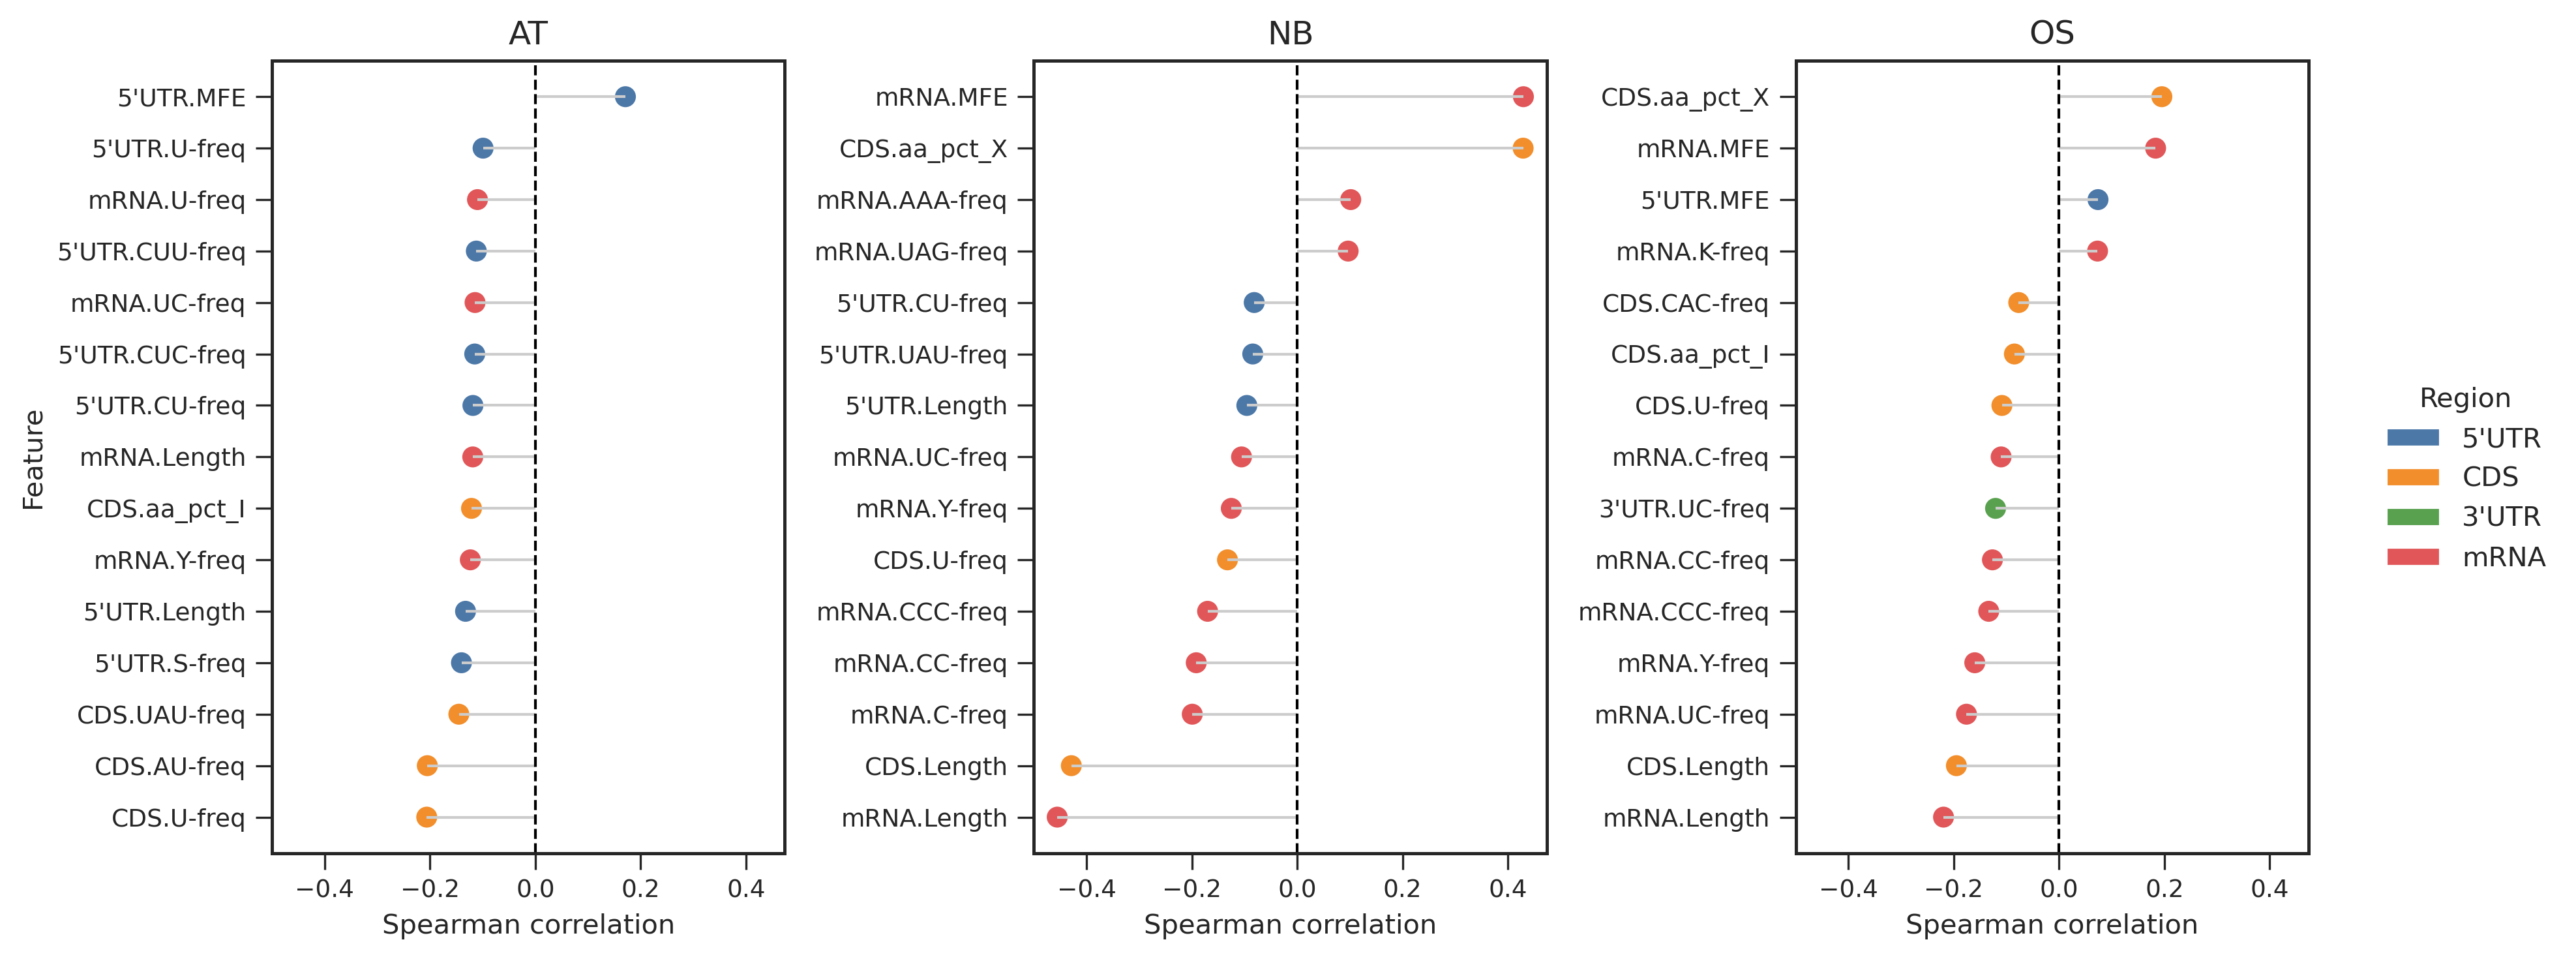

In [13]:
# ============================================
# Candidate feature–PR associations
# Top continuous associations
# ============================================

top_n = 15

fig, axes = plt.subplots(1, 3, figsize=(12, 5), dpi=_PLOT_CFG["dpi"], sharex=True)

for ax, species in zip(axes, ["AT", "NB", "OS"]):

    temp = (
        association_df
        .loc[association_df["Species"] == species]
        .sort_values("Abs_r", ascending=False)
        .head(top_n)
        .sort_values("Spearman_r")
    )

    colors = [region_colors[r] for r in temp["Region"]]

    ax.hlines(temp["Feature"], 0, temp["Spearman_r"], color="0.8", lw=1)
    ax.scatter(temp["Spearman_r"], temp["Feature"], s=45, c=colors)

    ax.axvline(0, color="black", ls="--", lw=1)

    ax.set_title(species)
    format_axis(
        ax,
        xlabel="Spearman correlation",
        ylabel="Feature" if ax is axes[0] else None,
    )

region_handles = [Patch(facecolor=c, label=l) for l, c in region_colors.items()]

fig.legend(region_handles, region_colors.keys(), title="Region",
           frameon=False, loc="center left", bbox_to_anchor=(1.01, 0.5))

plt.tight_layout()
plt.show()

In [14]:
# ============================================
# Top vs Bottom PR groups
# ============================================

group_rows = []

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]
    df = candidate_master_df.loc[candidate_master_df["Species"] == species].copy()

    q10 = df["observed_raw"].quantile(0.10)
    q90 = df["observed_raw"].quantile(0.90)

    df["PR_group"] = "Middle"
    df.loc[df["observed_raw"] <= q10, "PR_group"] = "Bottom"
    df.loc[df["observed_raw"] >= q90, "PR_group"] = "Top"

    group_rows.append(df)

candidate_group_df = pd.concat(group_rows, ignore_index=True)

print("PR groups")
display(
    candidate_group_df
    .groupby(["Species", "PR_group"])
    .size()
    .rename("n")
    .reset_index()
)

print("\nCombined dataset")
print(candidate_group_df.shape)

display(
    candidate_group_df[
        [
            "Species",
            "var_id",
            "observed_raw",
            "PR_group",
        ]
    ].head()
)

PR groups


,Species,PR_group,n
0,AT,Bottom,713
1,AT,Middle,5699
2,AT,Top,714
3,NB,Bottom,539
4,NB,Middle,4303
5,NB,Top,539
6,OS,Bottom,556
7,OS,Middle,4440
8,OS,Top,556



Combined dataset
(18059, 71)


,Species,var_id,observed_raw,PR_group
0,AT,AT5G05370.1.1591901.1590815,0.632897,Middle
1,AT,AT5G16060.1.5246121.5247413,0.365525,Middle
2,AT,AT2G34160.1.14426246.14427367,0.600538,Middle
3,AT,AT5G54600.1.22183004.22184509,0.544256,Middle
4,AT,AT2G23340.1.9937988.9938873,1.047809,Top


In [15]:
# ============================================
# Top vs Bottom PR feature comparison
# ============================================

from statsmodels.stats.multitest import multipletests

def cliffs_delta(x, y):

    x = np.asarray(x)
    y = np.asarray(y)

    diff = np.subtract.outer(x, y)
    return (np.sum(diff > 0) - np.sum(diff < 0)) / (len(x) * len(y))


comparison_rows = []

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]
    df = candidate_group_df.loc[candidate_group_df["Species"] == species]

    top_df = df.loc[df["PR_group"] == "Top"]
    bottom_df = df.loc[df["PR_group"] == "Bottom"]

    temp, pvals = [], []

    for feature in candidate_features:

        x = top_df[feature].dropna()
        y = bottom_df[feature].dropna()

        stat, p = stats.mannwhitneyu(x, y, alternative="two-sided")
        delta = cliffs_delta(x, y)

        temp.append({
            "Species": species,
            "Feature": feature,
            "Region": feature_meta_lookup.loc[feature, "Region"],
            "Feature_type": feature_meta_lookup.loc[feature, "Feature_type"],
            "Top_median": x.median(),
            "Bottom_median": y.median(),
            "Median_difference": x.median() - y.median(),
            "Cliff_delta": delta,
            "Abs_Cliff_delta": abs(delta),
            "P_value": p,
        })

        pvals.append(p)

    _, qvals, _, _ = multipletests(pvals, method="fdr_bh")

    for row, q in zip(temp, qvals):
        row["FDR"] = q
        row["Direction"] = "Higher in Top" if row["Cliff_delta"] > 0 else "Higher in Bottom"

    comparison_rows.extend(temp)

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values(["Species", "Abs_Cliff_delta"], ascending=[True, False])
    .reset_index(drop=True)
)

print("Top vs Bottom PR feature comparison")
print(comparison_df.shape)

display(comparison_df.groupby("Species").head(15))

Top vs Bottom PR feature comparison
(183, 12)


,Species,Feature,Region,Feature_type,Top_median,Bottom_median,Median_difference,Cliff_delta,Abs_Cliff_delta,P_value,FDR,Direction
0,AT,CDS.U-freq,CDS,Nucleotide_kmer_freq,238.461538,257.142857,-18.681319,-0.349315,0.349315,3.182727e-30,1.941463e-28,Higher in Bottom
1,AT,CDS.AU-freq,CDS,Nucleotide_kmer_freq,55.045872,64.000000,-8.954128,-0.339161,0.339161,1.375668e-28,4.195787e-27,Higher in Bottom
2,AT,5'UTR.MFE,5'UTR,RNA_structure_MFE,-6.900000,-13.060000,6.160000,0.266725,0.266725,2.503523e-18,5.090497e-17,Higher in Top
3,AT,5'UTR.S-freq,5'UTR,Nucleotide_kmer_freq,388.321995,431.034483,-42.712487,-0.246000,0.246000,8.606769e-16,1.098576e-14,Higher in Bottom
4,AT,mRNA.Y-freq,mRNA,Nucleotide_kmer_freq,483.333251,497.931034,-14.597783,-0.245841,0.245841,9.004724e-16,1.098576e-14,Higher in Bottom
5,AT,CDS.UAU-freq,CDS,Nucleotide_kmer_freq,8.547009,10.822511,-2.275502,-0.233951,0.233951,1.949424e-14,1.981915e-13,Higher in Bottom
6,AT,5'UTR.CUU-freq,5'UTR,Nucleotide_kmer_freq,14.185111,24.390244,-10.205133,-0.208131,0.208131,2.896816e-12,2.524368e-11,Higher in Bottom
7,AT,mRNA.UC-freq,mRNA,Nucleotide_kmer_freq,69.698451,73.783359,-4.084909,-0.198695,0.198695,8.144933e-11,5.520454e-10,Higher in Bottom
8,AT,5'UTR.Length,5'UTR,Length,53.000000,63.000000,-10.000000,-0.198029,0.198029,9.385564e-11,5.725194e-10,Higher in Bottom
9,AT,5'UTR.CUC-freq,5'UTR,Nucleotide_kmer_freq,11.634199,22.222222,-10.588023,-0.197059,0.197059,2.961842e-11,2.258405e-10,Higher in Bottom
